In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.patches as mpatches

import seaborn as sns
import function as f
import cartopy.crs as ccrs
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.stats import uniform

import warnings

In [2]:
figpath = '../../results/'
figformat = 'pdf'
dpi=500

**Supplemental Section 1**  
First, plotting solution spaces where variable fluxes are used 

In [3]:
def box_model(flux,pbl,measurements,dt=3600,dy=100000,start_date='6/1/2017',end_date='6/15/2017',spinup=5,groupby=False,obsmerge=True,upw_conc=1,hg_ft=1.5,pbl_var='avg_pblh_roll',wind_var='avg_windmag_roll',roll=5):
    '''
    Based on Seinfeld and Pandis Ch 25, equations 25.13 and 25.14
    '''
    
    time = pd.date_range(start=start_date,end=end_date,freq='1H')
    z_s = 0                                                                            #m
    m_air = 0.02897                                                                    #kg mol-1

    hg_box = 2                 #ng m-3

    box_ar = np.array(hg_box)
    ent_ar = np.array([])
    upw_ar = np.array([])
    flx_ar = np.array([])
    
    for i in list(range(0,len(time))):
        pbl_index = int(np.rint((i/24-np.floor(i/24))*24)) #This provides the number of the hour for each day of the timeseries, will take from average pbl
        z_pbl = pbl.iloc[pbl_index][pbl_var]               #m
        z_pblm1 = pbl.iloc[pbl_index-1][pbl_var]           #m
        windmag = pbl.iloc[pbl_index][wind_var]            #m s-1

        dpbl_z = z_pbl-z_pblm1                             #z hr-1

        if dpbl_z>0:
            hg_ent = ((dpbl_z/(z_pbl))*(hg_ft-hg_box))     #ng m-3 hr-1
        else:
            hg_ent = 0

        hg_upw = (windmag/dy)*(upw_conc-hg_box)*dt         #ng m-3 hr-1; windmag in units of m s-1, dt=3600 converts to m hr-1

        if len(flux) == 1:
            hg_flx = flux/z_pbl                                #ng m-3 hr-1; flux in units of ng m-2 hr-1
        if len(flux) == 24:
            hg_flx = flux[pbl_index]/z_pbl

        hg_box = hg_box+hg_ent+hg_upw+hg_flx               #hg_box represents new concentration after 1 hour timestep

        box_ar = np.append(box_ar,hg_box)
        ent_ar = np.append(ent_ar,hg_ent)
        upw_ar = np.append(upw_ar,hg_upw)
        flx_ar = np.append(flx_ar,hg_flx)
    boxmodel = pd.DataFrame({'time':time,'hg_box':box_ar[1:],'hg_ent':ent_ar,'hg_upw':upw_ar,'hg_flx':flx_ar})
    boxmodel = boxmodel.set_index('time')
    boxmodel = boxmodel[boxmodel.index>time[24*spinup]]
    boxmodel['hour'] = boxmodel.index.hour
    
    if groupby == True:
        boxmodel = boxmodel.groupby('hour').mean()
        if obsmerge == True:
            boxmodel = pd.merge(boxmodel,measurements,left_index=True,right_index=True)
            
            #boxmodel = pd.merge(boxmodel,NY20['GEM'],left_index=True,right_index=True)
            #boxmodel = boxmodel.rename(columns={'GEM':'NY20'})
            #boxmodel = pd.merge(boxmodel,NY06['GEM'],left_index=True,right_index=True)
            #boxmodel = boxmodel.rename(columns={'GEM':'NY06'})
            #boxmodel = pd.merge(boxmodel,NJ30['GEM'],left_index=True,right_index=True)
            #boxmodel = boxmodel.rename(columns={'GEM':'NJ30'})
            #boxmodel = pd.merge(boxmodel,VT99['GEM'],left_index=True,right_index=True)
            #boxmodel = boxmodel.rename(columns={'GEM':'VT99'})
            #boxmodel['urban'] = ((boxmodel['NY06'].interpolate()+boxmodel['NJ30'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()
            #boxmodel['rural'] = ((boxmodel['NY20'].interpolate()+boxmodel['VT99'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()
        return boxmodel
    else:
        return boxmodel

def optimal_flux(obs,upw_conc,hg_ft,fluxes,measurements,var='urban',option='standard'):

    prob = 0
    f_opt = 0
    measure = measurements[var]
    #measure = box_model(0,obs,measurements,upw_conc=upw_conc,hg_ft=hg_ft,groupby=True,obsmerge=True)[var]

    mod = box_model(fluxes,obs,measurements,upw_conc=upw_conc,hg_ft=hg_ft,groupby=True,obsmerge=False)['hg_box']

    if option=='standard':
        mod_prob = norm.pdf(mod,loc=measure,scale=0.05).mean()
    if option=='mean':
        mod_prob = norm.pdf(mod.mean(),loc=measure.mean())

    if mod_prob>prob:
        f_opt = f
        prob = mod_prob

    return f_opt,prob

In [4]:
def bm_wrapper_urb(x):
    a,b,c,d,e,f = x
    
    p0 = np.ones(4)*a
    p1 = np.ones(4)*b
    p2 = np.ones(4)*c
    p3 = np.ones(4)*d
    p4 = np.ones(4)*e
    p5 = np.ones(4)*f
    
    flx_24 = np.append([p0],[p1,p2,p3,p4,p5])
    
    mod = box_model(flx_24,pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True,obsmerge=False)['hg_box']
    
    return sum((mod - measurements['urban'])**2)

def bm_wrapper_rur(x):
    a,b,c,d,e,f = x
    
    p0 = np.ones(4)*a
    p1 = np.ones(4)*b
    p2 = np.ones(4)*c
    p3 = np.ones(4)*d
    p4 = np.ones(4)*e
    p5 = np.ones(4)*f
    
    flx_24 = np.append([p0],[p1,p2,p3,p4,p5])
    
    mod = box_model(flx_24,pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True,obsmerge=False)['hg_box']
    
    return sum((mod - measurements['rural'])**2)


def bm_converter(x_opt):
    a,b,c,d,e,f = x_opt
    
    p0 = np.ones(4)*a
    p1 = np.ones(4)*b
    p2 = np.ones(4)*c
    p3 = np.ones(4)*d
    p4 = np.ones(4)*e
    p5 = np.ones(4)*f
    
    flx_24 = np.append([p0],[p1,p2,p3,p4,p5])
    
    mod = box_model(flx_24,pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True,obsmerge=False)['hg_box']
    
    return mod

def bm_converter_flux(x_opt):
    a,b,c,d,e,f = x_opt
    
    p0 = np.ones(4)*a
    p1 = np.ones(4)*b
    p2 = np.ones(4)*c
    p3 = np.ones(4)*d
    p4 = np.ones(4)*e
    p5 = np.ones(4)*f
    
    flx_24 = np.append([p0],[p1,p2,p3,p4,p5])
        
    return flx_24


In [5]:
month = 6
roll = 5
shift = -5 #shifting to EST from UTC
wthresh = 25
option = 'mean'  #optimization strategy


In [6]:
path = '../../data/GCdata/GC_output/'
file = '/GEOSChem.SpeciesConcHF.2019'+str(month).zfill(2)+'01_0000z.nc4'#'/OutputDir/GEOSChem.SpeciesConcHF.20190[6-8]01_0000z.nc4'

base_s = xr.open_mfdataset(path+'STND'+file)
base_n = xr.open_mfdataset(path+'NEST'+file)

proj = ccrs.PlateCarree()

#getting lat/lon for ticks
s_lat = base_s.lat_bnds.values[:,0]
s_lon = base_s.lon_bnds.values[:,0]
n_lat = base_n.lat_bnds.values[:,0]
n_lon = base_n.lon_bnds.values[:,0]

In [7]:
bronx = [-73.8782,40.8680]
nbrunswick = [-74.4226,40.4728]
underhill = [-72.8684,44.5283]
huntington = [-74.2231,43.9731]

In [8]:
###Reading in Met data###

EWR,EWR_df = f.open_pbl(month=month,wthresh=wthresh,dirpath='../../data/pblh/')
BDL,BDL_df = f.open_pbl(month=month,loc='BDL',wthresh=wthresh,dirpath='../../data/pblh/')
MHT,MHT_df = f.open_pbl(month=month,loc='MHT',wthresh=wthresh,dirpath='../../data/pblh/')

#processing pbl data for nearby airports
pbl = pd.DataFrame({'EWR_pblh':EWR_df['pblh'],
                        'BDL_pblh':BDL_df['pblh'],
                        'MHT_pblh':MHT_df['pblh'],
                        'EWR_windmag':EWR_df['windmag'],
                        'BDL_windmag':BDL_df['windmag'],
                        'MHT_windmag':MHT_df['windmag']})

pbl['avg_pblh'] = pbl[['EWR_pblh', 'BDL_pblh']].mean(axis=1, skipna=True) #, 'MHT_pblh'
pbl['avg_pblh_roll'] = pbl['avg_pblh'].rolling(roll,center=True,min_periods=1).mean()

pbl['avg_windmag'] = pbl[['EWR_windmag', 'BDL_windmag']].mean(axis=1, skipna=True) #, 'MHT_windmag'
pbl['avg_windmag_roll'] = pbl['avg_windmag'].rolling(roll,center=True,min_periods=1).mean()



In [9]:
%%capture --no-stdout

### Reading in NADP data ###
Amnet=pd.read_csv('../../data/NADP/AMNET-NE-h.csv',na_values=(-9))
Amnet['collStart'] = pd.to_datetime(Amnet['collStart'])
Amnet['collEnd'] = pd.to_datetime(Amnet['collEnd'])
Amnet = Amnet.set_index('collStart')

#subsetting sites of interest
start = '2011-01-01'#'2014-01-01'
end = '2020-01-01'

Amnet = Amnet[Amnet.index>start]
Amnet = Amnet[Amnet.index<end]
Amnet_all = Amnet.copy()
Amnet = Amnet[Amnet.index.month==month]
Amnet['hour'] = Amnet.index.hour 

#extracting monthly diel cycles for all interesting sites
NJ54 = Amnet[Amnet['SiteID']=='NJ54'].groupby('hour').mean()
NJ30 = Amnet[Amnet['SiteID']=='NJ30'].groupby('hour').mean()
NY06 = Amnet[Amnet['SiteID']=='NY06'].groupby('hour').mean()
NY20 = Amnet[Amnet['SiteID']=='NY20'].groupby('hour').mean()
VT99 = Amnet[Amnet['SiteID']=='VT99'].groupby('hour').mean()

NJ30_h = Amnet_all[Amnet_all['SiteID']=='NJ30']
NY06_h = Amnet_all[Amnet_all['SiteID']=='NY06']
NY20_h = Amnet_all[Amnet_all['SiteID']=='NY20']
VT99_h = Amnet_all[Amnet_all['SiteID']=='VT99']


In [10]:
#making dataframe containing all Hg0 observations and regional averages

measurements = pd.merge(NY20['GEM'],NY06['GEM'],left_index=True,right_index=True)
measurements = measurements.rename(columns={'GEM_x':'NY20','GEM_y':'NY06'})
measurements = pd.merge(measurements,NJ30['GEM'],left_index=True,right_index=True)
measurements = measurements.rename(columns={'GEM':'NJ30'})
measurements = pd.merge(measurements,VT99['GEM'],left_index=True,right_index=True)
measurements = measurements.rename(columns={'GEM':'VT99'})
measurements['urban'] = ((measurements['NY06'].interpolate()+measurements['NJ30'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()
measurements['rural'] = ((measurements['NY20'].interpolate()+measurements['VT99'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()


In [11]:
%%capture --no-stdout

### Read in GEOS-Chem data ###

base_st = f.HgConversion(base_s['SpeciesConcVV_Hg0'].isel(lev=0).shift(time=shift).groupby('time.hour').mean())
base_nt = f.HgConversion(base_n['SpeciesConcVV_Hg0'].isel(lev=0).shift(time=shift).groupby('time.hour').mean())

bronx_st = base_st.sel(lat=bronx[1],lon=bronx[0],method='nearest').to_dataframe()
bronx_nt = base_nt.sel(lat=bronx[1],lon=bronx[0],method='nearest').to_dataframe()

nbrunswick_st = base_st.sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').to_dataframe()
nbrunswick_nt = base_nt.sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').to_dataframe()

underhill_st = base_st.sel(lat=underhill[1],lon=underhill[0],method='nearest').to_dataframe()
underhill_nt = base_nt.sel(lat=underhill[1],lon=underhill[0],method='nearest').to_dataframe()

huntington_st = base_st.sel(lat=huntington[1],lon=huntington[0],method='nearest').to_dataframe()
huntington_nt = base_nt.sel(lat=huntington[1],lon=huntington[0],method='nearest').to_dataframe()
#huntington_st = base_st.sel(lat=huntington[1],method='nearest').sel(lon=huntington[0],method='nearest').to_dataframe()
#huntington_nt = base_nt.sel(lat=huntington[1],method='nearest').sel(lon=huntington[0],method='nearest').to_dataframe()

In [12]:
#okay, now reading in results from test

rural_con = np.load('../../data/boxmod_opt/flux_rural_solspace_supplemental_06.npy')
urban_con = np.load('../../data/boxmod_opt/flux_urban_solspace_supplemental_06.npy')

rural_sci = np.load('../../data/boxmod_opt/flux_rural_solspace_supplementalscipy_06.npy')
urban_sci = np.load('../../data/boxmod_opt/flux_urban_solspace_supplementalscipy_06.npy')

rural_sci_ss = rural_sci.mean(1).transpose()
urban_sci_ss = urban_sci.mean(1).transpose()

uw_conc = np.linspace(1,2,5)
ft_conc = np.linspace(1,2,5)

In [13]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap


top = cm.get_cmap('Blues_r', 128)
bottom = cm.get_cmap('Reds', 128)

newcolors = np.vstack((top(np.linspace(0.1, 0.9, 128)),
                       bottom(np.linspace(0.1, 0.9, 128))))
newcmp = ListedColormap(newcolors, name='OrangeBlue')
cmap = newcmp


/tmp/ipykernel_985/3835991603.py:38: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  cbar = fig.colorbar(g)


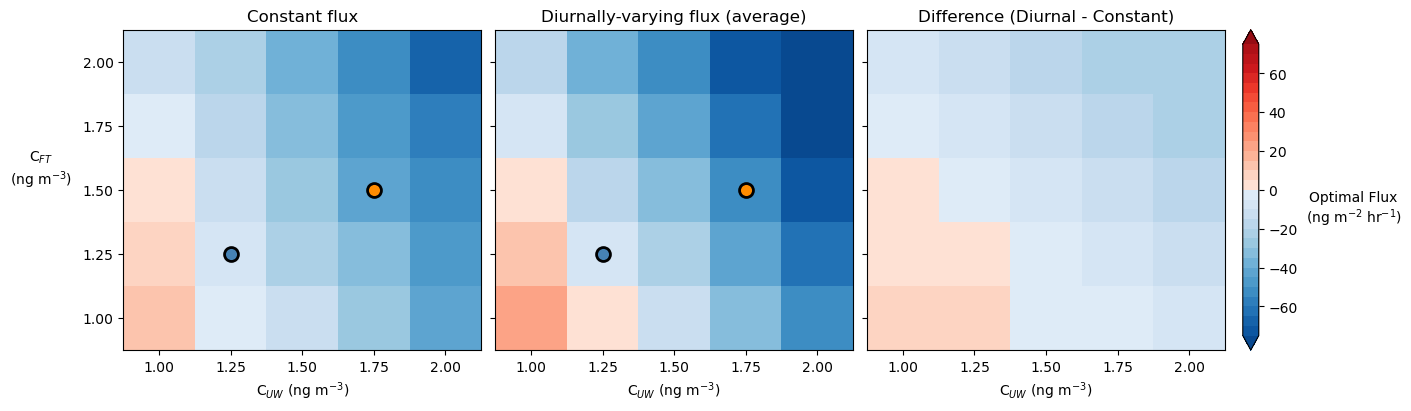

In [14]:
alpha = 0.4

bounds = np.arange(-75, 76, 5)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256,extend='both')

#bounds_shade = np.array([0,2,4,4.74,4.76])#np.array([0,0.9,1.4,2])
#norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

fig,ax=plt.subplots(1,3,figsize=(14,4),sharex=True,sharey=True,layout='constrained')
g = ax[0].pcolormesh(uw_conc,ft_conc,rural_con,norm=norm,cmap=cmap)
ax[1].pcolormesh(uw_conc,ft_conc,rural_sci_ss,norm=norm,cmap=cmap)
ax[2].pcolormesh(uw_conc,ft_conc,(rural_sci_ss-rural_con),norm=norm,cmap=cmap)
#plt.colorbar(g)

#add titles
ax[0].set_title('Constant flux')
ax[1].set_title('Diurnally-varying flux (average)')
ax[2].set_title('Difference (Diurnal - Constant)')

#add xlabels
ax[0].set_xticks([1,1.25,1.5,1.75,2])
ax[0].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
ax[1].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
ax[2].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')

#add ylabels
ax[0].set_yticks([1,1.25,1.5,1.75,2])
ax[0].set_ylabel('C$_{FT}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

#add scatter
ax[0].scatter(1.25,1.25,marker='.',c='steelblue',edgecolor='black',s=400,linewidth=2)
ax[1].scatter(1.25,1.25,marker='.',c='steelblue',edgecolor='black',s=400,linewidth=2)

ax[0].scatter(1.75,1.5,marker='.',c='darkorange',edgecolor='black',s=400,linewidth=2)
ax[1].scatter(1.75,1.5,marker='.',c='darkorange',edgecolor='black',s=400,linewidth=2)

#colorbar
cbar = fig.colorbar(g)
cbar.set_label('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=40)
plt.savefig(figpath+'Supplemental_ruralSS.'+figformat,dpi=dpi,transparent=True)

In [15]:
#okay, now lets make multipanel comparison of the flux and the diurnal concentrations

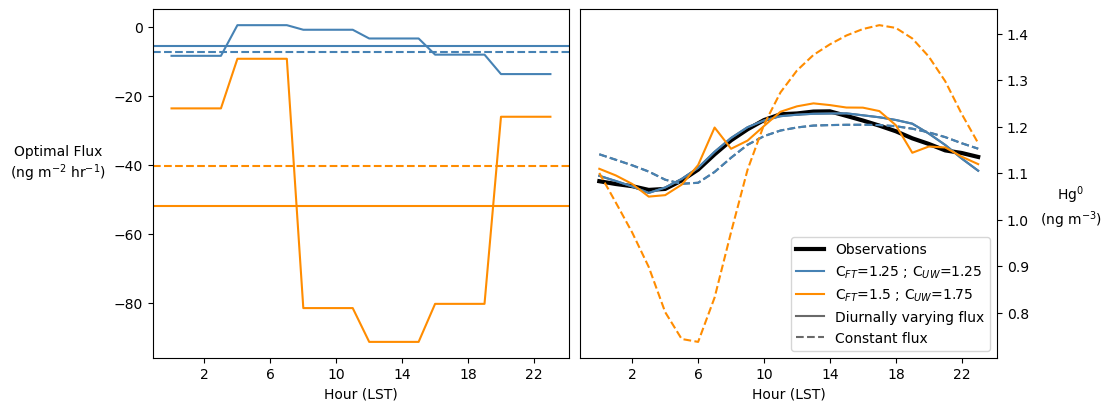

In [16]:
ft=1.25
uw=1.25

fig,ax=plt.subplots(1,2,sharex=True,figsize=(11,4),layout='constrained')

#first, fluxes
ax[0].plot(bm_converter_flux(rural_sci[1,:,1]),c='steelblue')
ax[0].axhline(bm_converter_flux(rural_sci[1,:,1]).mean(),c='steelblue')
ax[0].axhline(rural_con[1,1],c='steelblue',linestyle='--')

#then, concentrations
ax[1].plot(measurements['rural'],c='black',linewidth=3,label='Observations')
ax[1].plot(measurements['rural'],c='steelblue',linewidth=1.5,label='C$_{FT}$=1.25 ; C$_{UW}$=1.25',zorder=0)
ax[1].plot(measurements['rural'],c='darkorange',linewidth=1.5,label='C$_{FT}$=1.5 ; C$_{UW}$=1.75',zorder=0)
ax[1].plot(bm_converter(rural_sci[1,:,1]),c='dimgray',label='Diurnally varying flux')
ax[1].plot(bm_converter(rural_sci[1,:,1]),c='steelblue')
ax[1].plot(f.box_model(rural_con[1,1],pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box'],linestyle='--',c='dimgray',label='Constant flux')
ax[1].plot(f.box_model(rural_con[1,1],pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box'],linestyle='--',c='steelblue')

#adding second point
ft=1.5
uw=1.75
#first, fluxes
ax[0].plot(bm_converter_flux(rural_sci[3,:,2]),c='darkorange')
ax[0].axhline(bm_converter_flux(rural_sci[3,:,2]).mean(),c='darkorange')
ax[0].axhline(rural_con[2,3],c='darkorange',linestyle='--')

#then, concentrations
ax[1].plot(bm_converter(rural_sci[3,:,2]),c='darkorange')
ax[1].plot(f.box_model(rural_con[2,3],pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box'],c='darkorange',linestyle='--')

#adding plot features
ax[0].set_ylabel('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=40)
ax[0].set_xticks(np.arange(2,24,4))
ax[0].set_xlabel('Hour (LST)')

ax[1].set_xlabel('Hour (LST)')
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")
ax[1].set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

#now setting up legend
ax[1].legend()
plt.savefig(figpath+'Supplemental_rural_fluxconc.'+figformat,dpi=dpi,transparent=True)

/tmp/ipykernel_985/295252918.py:38: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  cbar = fig.colorbar(g)


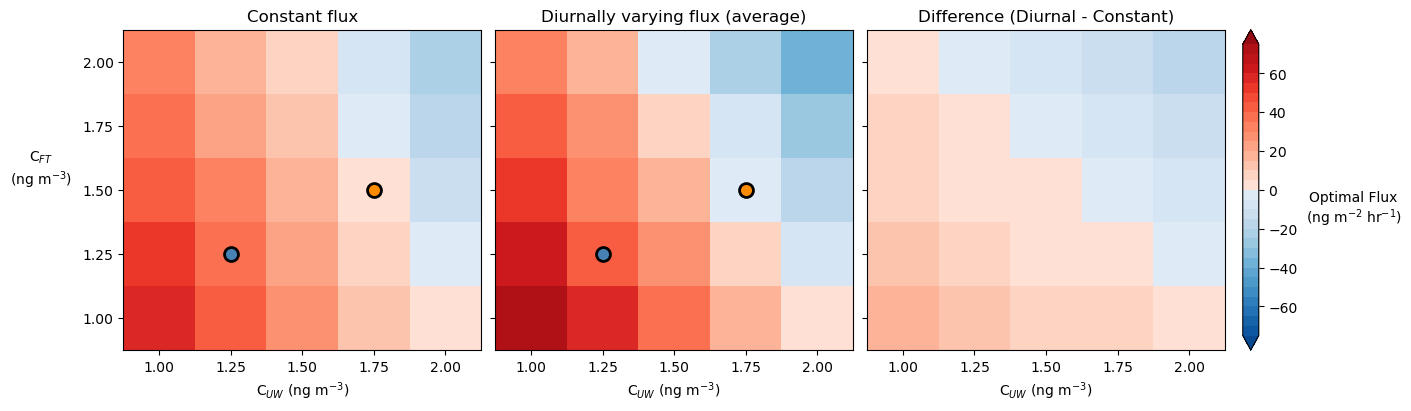

In [17]:
alpha = 0.4

bounds = np.arange(-75, 76, 5)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256,extend='both')

bounds_shade = np.array([0,2,4,4.74,4.76])#np.array([0,0.9,1.4,2])
norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

fig,ax=plt.subplots(1,3,figsize=(14,4),sharex=True,sharey=True,layout='constrained')
g = ax[0].pcolormesh(uw_conc,ft_conc,urban_con,norm=norm,cmap=cmap)
ax[1].pcolormesh(uw_conc,ft_conc,urban_sci_ss,norm=norm,cmap=cmap)
ax[2].pcolormesh(uw_conc,ft_conc,(urban_sci_ss-urban_con),norm=norm,cmap=cmap)
#plt.colorbar(g)

#add titles
ax[0].set_title('Constant flux')
ax[1].set_title('Diurnally varying flux (average)')
ax[2].set_title('Difference (Diurnal - Constant)')

#add xlabels
ax[0].set_xticks([1,1.25,1.5,1.75,2])
ax[0].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
ax[1].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
ax[2].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')

#add ylabels
ax[0].set_yticks([1,1.25,1.5,1.75,2])
ax[0].set_ylabel('C$_{FT}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

#add scatter
ax[0].scatter(1.25,1.25,marker='.',c='steelblue',edgecolor='black',s=400,linewidth=2)
ax[1].scatter(1.25,1.25,marker='.',c='steelblue',edgecolor='black',s=400,linewidth=2)

ax[0].scatter(1.75,1.5,marker='.',c='darkorange',edgecolor='black',s=400,linewidth=2)
ax[1].scatter(1.75,1.5,marker='.',c='darkorange',edgecolor='black',s=400,linewidth=2)

#colorbar
cbar = fig.colorbar(g)
cbar.set_label('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=40)
plt.savefig(figpath+'Supplemental_urbanSS.'+figformat,dpi=dpi,transparent=True)

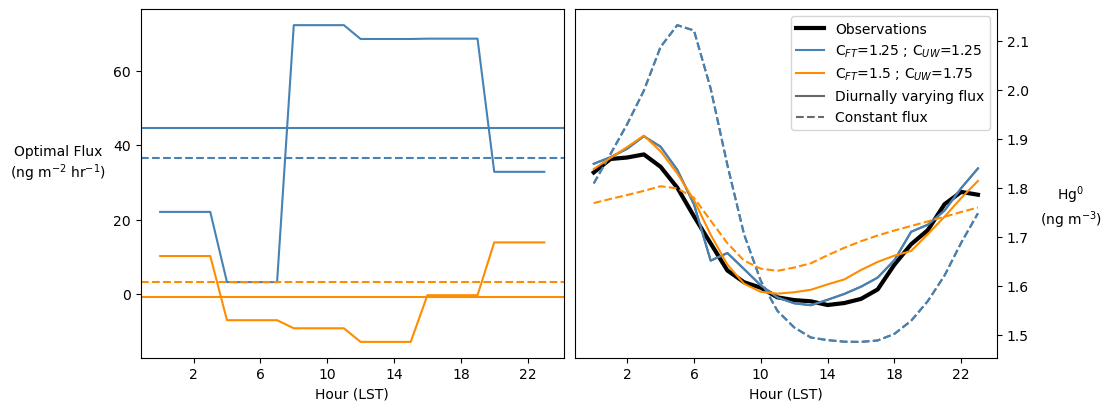

In [18]:
ft=1.25
uw=1.25

fig,ax=plt.subplots(1,2,sharex=True,figsize=(11,4),layout='constrained')

#first, fluxes
ax[0].plot(bm_converter_flux(urban_sci[1,:,1]),c='steelblue')
ax[0].axhline(bm_converter_flux(urban_sci[1,:,1]).mean(),c='steelblue')
ax[0].axhline(urban_con[1,1],c='steelblue',linestyle='--')

#then, concentrations
ax[1].plot(measurements['urban'],c='black',linewidth=3,label='Observations')
ax[1].plot(measurements['urban'],c='steelblue',linewidth=1.5,label='C$_{FT}$=1.25 ; C$_{UW}$=1.25',zorder=0)
ax[1].plot(measurements['urban'],c='darkorange',linewidth=1.5,label='C$_{FT}$=1.5 ; C$_{UW}$=1.75',zorder=0)
ax[1].plot(bm_converter(urban_sci[1,:,1]),c='dimgray',label='Diurnally varying flux')
ax[1].plot(bm_converter(urban_sci[1,:,1]),c='steelblue')
ax[1].plot(f.box_model(urban_con[1,1],pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box'],linestyle='--',c='dimgray',label='Constant flux')
ax[1].plot(f.box_model(urban_con[1,1],pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box'],linestyle='--',c='steelblue')

#adding second point
ft=1.5
uw=1.75
#first, fluxes
ax[0].plot(bm_converter_flux(urban_sci[3,:,2]),c='darkorange')
ax[0].axhline(bm_converter_flux(urban_sci[3,:,2]).mean(),c='darkorange')
ax[0].axhline(urban_con[2,3],c='darkorange',linestyle='--')

#then, concentrations
ax[1].plot(bm_converter(urban_sci[3,:,2]),c='darkorange')
ax[1].plot(f.box_model(urban_con[2,3],pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box'],c='darkorange',linestyle='--')

#adding plot features
ax[0].set_ylabel('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=40)
ax[0].set_xticks(np.arange(2,24,4))
ax[0].set_xlabel('Hour (LST)')

ax[1].set_xlabel('Hour (LST)')
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")
ax[1].set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

#now setting up legend
ax[1].legend()
plt.savefig(figpath+'Supplemental_urban_fluxconc.'+figformat,dpi=dpi,transparent=True)

**Supplemental Section 2**  
Here, showing that MERRA2 and observations have similar PBL diurnalities

In [19]:
#now reading in June
month=6
EWR,EWR_df = f.open_pbl(month=month,wthresh=wthresh,dirpath='../../data/pblh/')
BDL,BDL_df = f.open_pbl(month=month,loc='BDL',wthresh=wthresh,dirpath='../../data/pblh/')
MHT,MHT_df = f.open_pbl(month=month,loc='MHT',wthresh=wthresh,dirpath='../../data/pblh/')

#processing pbl data for nearby airports
pbl = pd.DataFrame({'EWR_pblh':EWR_df['pblh'],
                        'BDL_pblh':BDL_df['pblh'],
                        'MHT_pblh':MHT_df['pblh'],
                        'EWR_windmag':EWR_df['windmag'],
                        'BDL_windmag':BDL_df['windmag'],
                        'MHT_windmag':MHT_df['windmag']})

pbl['avg_pblh'] = pbl[['EWR_pblh', 'BDL_pblh']].mean(axis=1, skipna=True) #, 'MHT_pblh'
pbl['avg_pblh_roll'] = pbl['avg_pblh'].rolling(roll,center=True,min_periods=1).mean()

pbl['avg_windmag'] = pbl[['EWR_windmag', 'BDL_windmag']].mean(axis=1, skipna=True) #, 'MHT_windmag'
pbl['avg_windmag_roll'] = pbl['avg_windmag'].rolling(roll,center=True,min_periods=1).mean()

pbl_j = pbl.copy()

#now reading in december
month = 12
EWR,EWR_df = f.open_pbl(month=month,wthresh=wthresh,dirpath='../../data/pblh/')
BDL,BDL_df = f.open_pbl(month=month,loc='BDL',wthresh=wthresh,dirpath='../../data/pblh/')
MHT,MHT_df = f.open_pbl(month=month,loc='MHT',wthresh=wthresh,dirpath='../../data/pblh/')

#processing pbl data for nearby airports
pbl = pd.DataFrame({'EWR_pblh':EWR_df['pblh'],
                        'BDL_pblh':BDL_df['pblh'],
                        'MHT_pblh':MHT_df['pblh'],
                        'EWR_windmag':EWR_df['windmag'],
                        'BDL_windmag':BDL_df['windmag'],
                        'MHT_windmag':MHT_df['windmag']})

pbl['avg_pblh'] = pbl[['EWR_pblh', 'BDL_pblh']].mean(axis=1, skipna=True) #, 'MHT_pblh'
pbl['avg_pblh_roll'] = pbl['avg_pblh'].rolling(roll,center=True,min_periods=1).mean()

pbl['avg_windmag'] = pbl[['EWR_windmag', 'BDL_windmag']].mean(axis=1, skipna=True) #, 'MHT_windmag'
pbl['avg_windmag_roll'] = pbl['avg_windmag'].rolling(roll,center=True,min_periods=1).mean()

pbl_d = pbl.copy()


In [20]:
merra_june = xr.open_dataset('../../data/pblh/MERRA2/MERRA2.201706.pblh.2x25.nc4')
merra_june = merra_june.shift(time=-5)

merra_dec = xr.open_dataset('../../data/pblh/MERRA2/MERRA2.201712.pblh.2x25.nc4')
merra_dec = merra_dec.shift(time=-5)

In [21]:
merra_df = merra_june.sel(lat=40).sel(lon=-75)['PBLH'].to_dataframe(name='NJ')
merra_df['NY'] = merra_june.sel(lat=42).sel(lon=-75)['PBLH'].to_dataframe(name='NY')['NY']
merra_df['NY_us'] = merra_june.sel(lat=44).sel(lon=-75)['PBLH'].to_dataframe(name='NY_us')['NY_us']
merra_df['CT'] = merra_june.sel(lat=42).sel(lon=-72.5)['PBLH'].to_dataframe(name='CT')['CT']
merra_df['VT'] = merra_june.sel(lat=44).sel(lon=-72.5)['PBLH'].to_dataframe(name='VT')['VT']
merra_df['hour'] = merra_df.index.hour
merra_hour_j = merra_df.groupby('hour').mean()

In [22]:
merra_df = merra_dec.sel(lat=40).sel(lon=-75)['PBLH'].to_dataframe(name='NJ')
merra_df['NY'] = merra_dec.sel(lat=42).sel(lon=-75)['PBLH'].to_dataframe(name='NY')['NY']
merra_df['NY_us'] = merra_dec.sel(lat=44).sel(lon=-75)['PBLH'].to_dataframe(name='NY_us')['NY_us']
merra_df['CT'] = merra_dec.sel(lat=42).sel(lon=-72.5)['PBLH'].to_dataframe(name='CT')['CT']
merra_df['VT'] = merra_dec.sel(lat=44).sel(lon=-72.5)['PBLH'].to_dataframe(name='VT')['VT']
merra_df['hour'] = merra_df.index.hour
merra_hour_d = merra_df.groupby('hour').mean()

In [23]:
#add in plot comparing the raw pblh, windspeeds from observations and the rolled values

In [24]:
pbl

,EWR_pblh,BDL_pblh,MHT_pblh,EWR_windmag,BDL_windmag,MHT_windmag,avg_pblh,avg_pblh_roll,avg_windmag,avg_windmag_roll
hour,,,,,,,,,,
0,736.169184,551.342220,722.669315,5.895238,5.758007,8.119857,643.755702,614.671925,5.826623,5.451623
1,503.039870,751.665798,154.825619,4.468248,9.195018,3.127160,627.352834,608.045825,6.831633,5.491870
2,653.406900,492.407577,NaN,4.537434,2.855790,NaN,572.907238,614.722361,3.696612,5.739356
3,794.831334,381.503717,779.170073,6.125612,5.099610,10.607018,588.167526,600.017068,5.612611,5.323170
4,757.721353,525.135658,396.346795,5.889422,7.569180,6.082217,641.428506,581.718273,6.729301,4.633207
5,681.241743,459.216725,466.786626,4.337876,3.153507,3.704050,570.229234,562.236680,3.745691,4.465704
6,609.685348,462.032374,533.001727,3.707381,3.056260,3.959914,535.858861,543.953382,3.381820,3.959873
7,569.956342,381.042210,561.917369,3.206413,2.511779,3.571409,475.499276,532.671543,2.859096,3.220147
8,543.322855,450.179208,631.527823,3.501515,2.665394,6.940306,496.751032,522.248909,3.083455,2.952392


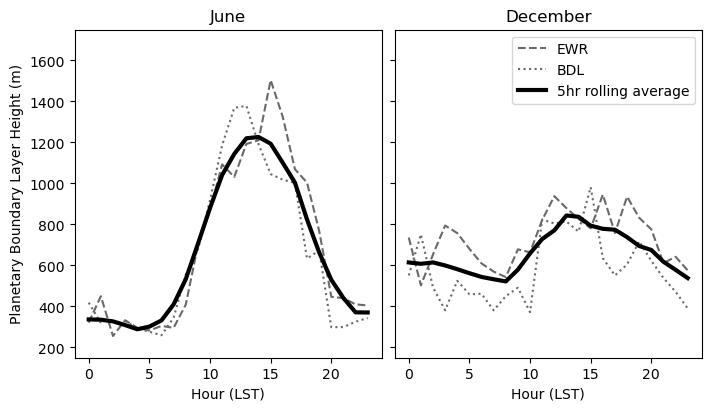

In [25]:
fig,ax=plt.subplots(1,2,figsize=(7, 4),sharex=True,sharey=True,layout='constrained')
ax[0].plot(pbl_j['EWR_pblh'],c='dimgray',linestyle='--')
ax[0].plot(pbl_j['BDL_pblh'],c='dimgray',linestyle=':')
ax[0].plot(pbl_j['avg_pblh_roll'],linewidth=3,c='black')

ax[1].plot(pbl_d['EWR_pblh'],label='EWR',c='dimgray',linestyle='--')
ax[1].plot(pbl_d['BDL_pblh'],label='BDL',c='dimgray',linestyle=':')
ax[1].plot(pbl_d['avg_pblh_roll'],linewidth=3,c='black',label='5hr rolling average')

ax[1].set_ylim(150,1750)
ax[1].set_xticks([0,5,10,15,20])
ax[1].legend()

ax[0].set_xlabel('Hour (LST)')
ax[1].set_xlabel('Hour (LST)')
ax[0].set_ylabel('Planetary Boundary Layer Height (m)')
ax[0].set_title('June')
ax[1].set_title('December')
plt.savefig(figpath+'Supplemental_PBLHsmoothing.'+figformat,dpi=dpi,transparent=True)

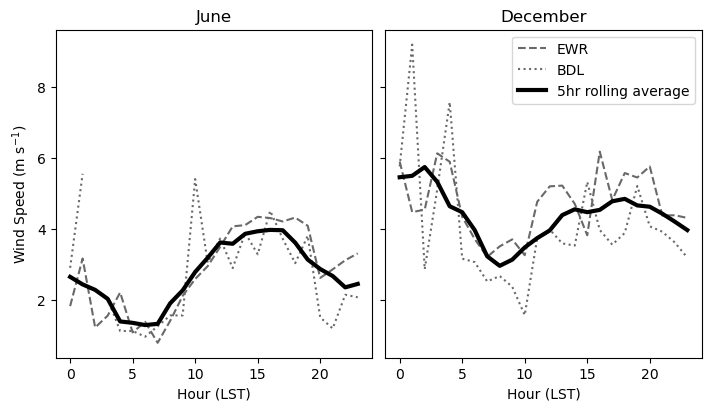

In [26]:
fig,ax=plt.subplots(1,2,figsize=(7, 4),sharex=True,sharey=True,layout='constrained')
ax[0].plot(pbl_j['EWR_windmag'],c='dimgray',linestyle='--')
ax[0].plot(pbl_j['BDL_windmag'],c='dimgray',linestyle=':')
ax[0].plot(pbl_j['avg_windmag_roll'],linewidth=3,c='black')

ax[1].plot(pbl_d['EWR_windmag'],label='EWR',c='dimgray',linestyle='--')
ax[1].plot(pbl_d['BDL_windmag'],label='BDL',c='dimgray',linestyle=':')
ax[1].plot(pbl_d['avg_windmag_roll'],linewidth=3,c='black',label='5hr rolling average')

#ax[1].set_ylim(150,1750)
ax[1].set_xticks([0,5,10,15,20])
ax[1].legend()

ax[0].set_xlabel('Hour (LST)')
ax[1].set_xlabel('Hour (LST)')
ax[0].set_ylabel('Wind Speed (m s$^{-1}$)')
ax[0].set_title('June')
ax[1].set_title('December')
plt.savefig(figpath+'Supplemental_WSPDsmoothing.'+figformat,dpi=dpi,transparent=True)

In [27]:
land = 'white'
water = '#7294b8'#'steelblue'#'lightslategrey'
boarder = 'black'

states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none')

lonmin = -80
lonmax = -70
latmin = 36
latmax = 48

/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


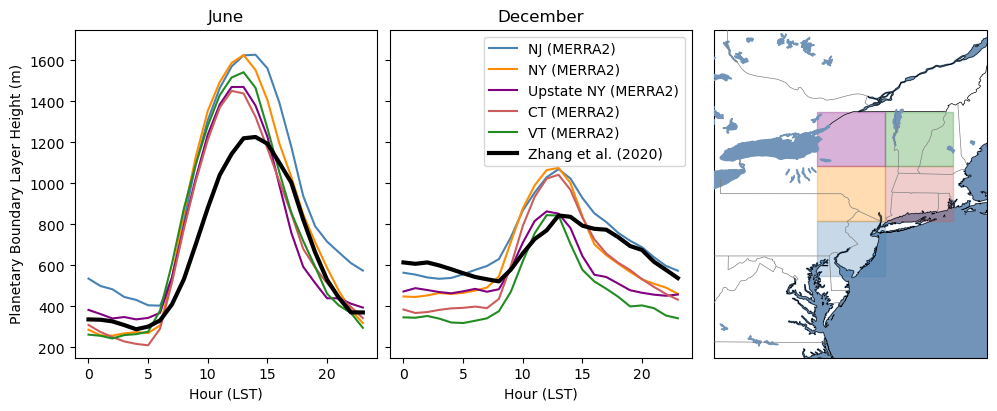

In [28]:
#fig,ax=plt.subplots(1,3,figsize=(10,4),layout='constrained')
fig = plt.figure(figsize=(10, 4),layout='constrained')

ax0 = fig.add_subplot(1, 3, 1)
ax0.plot(merra_hour_j['NJ'],label='NJ (MERRA2)',c='steelblue')
ax0.plot(merra_hour_j['NY'],label='NY (MERRA2)',c='darkorange')
ax0.plot(merra_hour_j['NY_us'],label='Upstate NY (MERRA2)',c='purple')
ax0.plot(merra_hour_j['CT'],label='CT (MERRA2)',c='indianred')
ax0.plot(merra_hour_j['VT'],label='VT (MERRA2)',c='forestgreen')
ax0.plot(pbl_j['avg_pblh_roll'],linewidth=3,c='black')

ax0.set_ylabel('Planetary Boundary Layer Height (m)')
ax0.set_xlabel('Hour (LST)')
ax0.set_ylim(150,1750)

ax1 = fig.add_subplot(1, 3, 2)
ax1.plot(merra_hour_d['NJ'],label='NJ (MERRA2)',c='steelblue')
ax1.plot(merra_hour_d['NY'],label='NY (MERRA2)',c='darkorange')
ax1.plot(merra_hour_d['NY_us'],label='Upstate NY (MERRA2)',c='purple')
ax1.plot(merra_hour_d['CT'],label='CT (MERRA2)',c='indianred')
ax1.plot(merra_hour_d['VT'],label='VT (MERRA2)',c='forestgreen')
ax1.plot(pbl_d['avg_pblh_roll'],linewidth=3,c='black',label='Zhang et al. (2020)')

ax1.legend()
ax1.set_yticklabels([])
ax1.set_xlabel('Hour (LST)')
ax1.set_ylim(150,1750)

#trying to add map to third panel
ax2 = fig.add_subplot(1, 3, 3,projection=ccrs.PlateCarree())

#data = merra_pblh.isel(time=25).sel(lat=slice(30,50),lon=slice(-80,-70))['PBLH']
#lat = data.lat
#lon = data.lon
#g = ax2.pcolormesh(lon,lat,data)
ax2.set_xticklabels([])
ax2.set_yticklabels([])
#cbar = plt.colorbar(g,pad=0.02)
ax2.add_feature(cfeature.LAND,color=land)
ax2.add_feature(cfeature.LAKES,color=water,zorder=10)
ax2.add_feature(cfeature.OCEAN,color=water)
ax2.add_feature(cfeature.COASTLINE,color=boarder,linewidth=0.4,zorder=10)
ax2.add_feature(cfeature.BORDERS,color=boarder,linewidth=0.5)
ax2.add_feature(states_provinces,linewidth=0.5,zorder=10,edgecolor='gray')
ax2.set_extent([lonmin,lonmax,latmin,latmax])

#NJ
ax2.add_patch(mpatches.Rectangle(xy=[-75-1.25,40-1], width=2.5, height=2,
                                facecolor='steelblue',
                                alpha=0.3,
                                edgecolor='steelblue',
                                linewidth=1,
                                transform=ccrs.PlateCarree()))
#NY
ax2.add_patch(mpatches.Rectangle(xy=[-75-1.25,42-1], width=2.5, height=2,
                                facecolor='darkorange',
                                alpha=0.3,
                                edgecolor='darkorange',
                                linewidth=1,
                                transform=ccrs.PlateCarree()))
#CT
ax2.add_patch(mpatches.Rectangle(xy=[-72.5-1.25,42-1], width=2.5, height=2,
                                facecolor='indianred',
                                alpha=0.3,
                                edgecolor='indianred',
                                linewidth=1,
                                transform=ccrs.PlateCarree()))
#upstate NY
ax2.add_patch(mpatches.Rectangle(xy=[-75-1.25,44-1], width=2.5, height=2,
                                facecolor='purple',
                                alpha=0.3,
                                edgecolor='purple',
                                linewidth=1,
                                transform=ccrs.PlateCarree()))

#VT
ax2.add_patch(mpatches.Rectangle(xy=[-72.5-1.25,44-1], width=2.5, height=2,
                                facecolor='forestgreen',
                                alpha=0.3,
                                edgecolor='forestgreen',
                                linewidth=1,
                                transform=ccrs.PlateCarree()))

ax0.set_title('June')
ax1.set_title('December')

plt.savefig(figpath+'Supplemental_PBLHcomparison.'+figformat,dpi=dpi,transparent=True)

**Supplemental Section 3**  
Here, comparing the effective magnitude of surface and chemical fluxes for urban and rural areas in nested GEOS-Chem simulations

In [29]:
bronx = [-73.8782,40.8680]
nbrunswick = [-74.4226,40.4728]
underhill = [-72.8684,44.5283]
huntington = [-74.2231,43.9731]

In [30]:
#need to determine the level where GC thinks the PBL is on average

In [31]:
#defining the 1976 std atmosphere (using values from S&P)
p_stdatm = np.array([1013,898,795,701.2,616.6,540.5,472.2,411.1,356.5,308,265,227,194,165,142,121,103,88.5,75.6,64.6,5.53]) #converts from hPa to Pa
T_stdatm = np.array([288,282,275,269,262,256,249,243,236,230,223,217,217,217,217,217,217,217,217,217,217]) #K
z_stdatm = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])*1000 #m

p_to_z = interp1d(p_stdatm,z_stdatm,fill_value='extrapolate')
z_to_p = interp1d(z_stdatm,p_stdatm,fill_value='extrapolate')

#p_to_z(1012)

In [33]:
#reading in necessary met (using 2x2.5 for efficiency, nested makes little difference when aggregated across region)
month=6
met = xr.open_dataset('../../data/pblh/MERRA2/MERRA2.2019'+str(month).zfill(2)+'.pblh.2x25.nc4')

In [35]:
path = '../../data/GCdata/GC_output/'
file = '/GEOSChem.SpeciesConcHF.2019'+str(month).zfill(2)+'01_0000z.nc4'

base_s = xr.open_mfdataset(path+'STND'+file).load()

In [36]:
%%capture --no-stdout

#calculating pressure at each gridbox
p_i = base_s['hyai']+(base_s['hybi']*(met['SLP'])/100)
p_m = p_i.rolling(ilev=2).mean().dropna('ilev')
p_m = p_m.assign_coords(ilev=(base_s.lev.values))
p_m = p_m.rename({'ilev':'lev'})
p_m = p_m.sel(lat=base_s['lat'],lon=base_s['lon']).resample(time='1H').mean()
base_s = xr.merge([base_s,p_m.to_dataset(name='P_m')])

In [37]:
%%capture --no-stdout

pprof_rur = base_s.sel(lat=(huntington[1]+underhill[1])/2,lon=(huntington[0]+underhill[0])/2,method='nearest')['P_m'].mean('time')
pprof_urb = base_s.sel(lat=(bronx[1]+nbrunswick[1])/2,lon=(bronx[0]+nbrunswick[0])/2,method='nearest')['P_m'].mean('time')

In [38]:
merra_june = xr.open_dataset('../../data/pblh/MERRA2/MERRA2.201706.pblh.2x25.nc4')
merra_june = merra_june.shift(time=-5)

merra_dec = xr.open_dataset('../../data/pblh/MERRA2/MERRA2.201712.pblh.2x25.nc4')
merra_dec = merra_dec.shift(time=-5)

In [39]:
merra_df = merra_june.sel(lat=40).sel(lon=-75)['PBLH'].to_dataframe(name='NJ')
merra_df['NY'] = merra_june.sel(lat=42).sel(lon=-75)['PBLH'].to_dataframe(name='NY')['NY']
merra_df['NY_us'] = merra_june.sel(lat=44).sel(lon=-75)['PBLH'].to_dataframe(name='NY_us')['NY_us']
merra_df['CT'] = merra_june.sel(lat=42).sel(lon=-72.5)['PBLH'].to_dataframe(name='CT')['CT']
merra_df['VT'] = merra_june.sel(lat=44).sel(lon=-72.5)['PBLH'].to_dataframe(name='VT')['VT']
merra_df['hour'] = merra_df.index.hour
merra_hour_j = merra_df.groupby('hour').mean()

In [40]:
merra_df = merra_dec.sel(lat=40).sel(lon=-75)['PBLH'].to_dataframe(name='NJ')
merra_df['NY'] = merra_dec.sel(lat=42).sel(lon=-75)['PBLH'].to_dataframe(name='NY')['NY']
merra_df['NY_us'] = merra_dec.sel(lat=44).sel(lon=-75)['PBLH'].to_dataframe(name='NY_us')['NY_us']
merra_df['CT'] = merra_dec.sel(lat=42).sel(lon=-72.5)['PBLH'].to_dataframe(name='CT')['CT']
merra_df['VT'] = merra_dec.sel(lat=44).sel(lon=-72.5)['PBLH'].to_dataframe(name='VT')['VT']
merra_df['hour'] = merra_df.index.hour
merra_hour_d = merra_df.groupby('hour').mean()

In [41]:
avg_pbl = (merra_hour_j['NJ'].mean()+merra_hour_j['NY'].mean()+merra_hour_j['CT'].mean()+merra_hour_j['NY_us'].mean()+merra_hour_j['VT'].mean())/5

In [42]:
avg_pbl_hPa = z_to_p(avg_pbl)

In [43]:
avg_pbl_hPa

array(923.89351202)

In [44]:
np.where(pprof_rur.values>avg_pbl_hPa)[0]

array([0, 1, 2, 3, 4, 5])

In [45]:
np.where(pprof_urb.values>avg_pbl_hPa)[0]

array([0, 1, 2, 3, 4, 5])

In [46]:
bronx = [-73.8782,40.8680]
nbrunswick = [-74.4226,40.4728]
underhill = [-72.8684,44.5283]
huntington = [-74.2231,43.9731]

In [56]:
#first, reading in the ft, uw concentrations for urban and rural
month = 6

datapath = '../../data/GCdata/GC_processed/'
mstr = str(month).zfill(2)
file = datapath+mstr+'/'

In [57]:
%%capture --no-stdout

def gc_netHg0(file,filename,method='mean'):
    n_f = xr.open_dataset(file+filename)
    n_f['net_ngm2hr'] = n_f['EmisTot_ngm2hr']-n_f['DryDep_Hg0_ngm2hr']

    if method == 'mean':
        r_flux = (((n_f['net_ngm2hr'].sel(lat=underhill[1],lon=underhill[0],method='nearest'))+(n_f['net_ngm2hr'].sel(lat=huntington[1],lon=huntington[0],method='nearest')))/2).values
        u_flux = (((n_f['net_ngm2hr'].sel(lat=bronx[1],lon=bronx[0],method='nearest'))+(n_f['net_ngm2hr'].sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest')))/2).values
        
    if method == 'max':
        r_flux = np.min([n_f['net_ngm2hr'].sel(lat=underhill[1],lon=underhill[0],method='nearest').values,n_f['net_ngm2hr'].sel(lat=huntington[1],lon=huntington[0],method='nearest').values])
        u_flux = np.max([n_f['net_ngm2hr'].sel(lat=bronx[1],lon=bronx[0],method='nearest').values,n_f['net_ngm2hr'].sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').values])

    return r_flux,u_flux

In [58]:
%%capture --no-stdout
r_f,u_f = gc_netHg0(file,'NetHg0Flux_'+mstr+'.nc4')
r_f3x,u_f3x = gc_netHg0(file,'NetHg0Flux_3x_'+mstr+'.nc4')
r_f7x,u_f7x = gc_netHg0(file,'NetHg0Flux_7x_'+mstr+'.nc4')
r_f10x,u_f10x = gc_netHg0(file,'NetHg0Flux_10x_'+mstr+'.nc4')

In [59]:
#06/16/2025: Adding in chemistry flux
def conversion(df):
    return df*100*100*100*3600/(6.022e23)*200.59*1e9

def chem_read(path,loc='urban',levs=0,pbl_level=5):
    '''
    Reading in average chemical flux for month of June accoring to GEOS-Chem
    '''
    
    gc = xr.open_dataset(path)

    if loc=='rural':
        lat=43.976
        lon=-74.206
    if loc=='urban':
        lat=40.898
        lon=-73.903
    
    if levs == 0:
        Hg = gc.isel(lev=0)[['Prod_Hg0','Prod_Hg2']].sel(lat=lat,method='nearest').sel(lon=lon,method='nearest').to_dataframe()

        Hg['Prod_Hg0'] = conversion(Hg['Prod_Hg0'])
        Hg['Prod_Hg2'] = conversion(Hg['Prod_Hg2'])
        Hg['Net_Hg0'] = Hg['Prod_Hg0']-Hg['Prod_Hg2']

    if levs == 'pbl_level':    
        Hg = gc.isel(lev=slice(0,pbl_level))[['Prod_Hg0','Prod_Hg2']].sel(lat=lat,method='nearest').sel(lon=lon,method='nearest').mean('lev').to_dataframe()

        Hg['Prod_Hg0'] = conversion(Hg['Prod_Hg0'])
        Hg['Prod_Hg2'] = conversion(Hg['Prod_Hg2'])
        Hg['Net_Hg0'] = Hg['Prod_Hg0']-Hg['Prod_Hg2']

    if levs == 'all':
        Hg = gc.sel(lat=lat,method='nearest').sel(lon=lon,method='nearest')

        Hg['Net_Hg0'] = Hg['Prod_Hg0']-Hg['Prod_Hg2']
        

    #Hg = Hg.shift(-4)

    #Hg['hour'] = Hg.index.hour
    #Hg = Hg.groupby('hour').mean()

    return Hg


In [70]:
path_std = '../../data/GCdata/GC_output/NEST/GEOSChem.ProdLoss.2019'+str(month).zfill(2)+'01_0000z.nc4'
path_3x = '../../data/GCdata/GC_output/ANT3/GEOSChem.ProdLoss.2019'+str(month).zfill(2)+'01_0000z.nc4'
path_7x = '../../data/GCdata/GC_output/ANT7/GEOSChem.ProdLoss.2019'+str(month).zfill(2)+'01_0000z.nc4'
path_10x = '../../data/GCdata/GC_output/ANT10/GEOSChem.ProdLoss.2019'+str(month).zfill(2)+'01_0000z.nc4'

In [71]:
%%capture --no-stdout

std_r_c = chem_read(path_std,loc='rural',levs='pbl_level')
r_c3x = chem_read(path_3x,loc='rural',levs='pbl_level')
r_c7x = chem_read(path_7x,loc='rural',levs='pbl_level')
r_c10x = chem_read(path_10x,loc='rural',levs='pbl_level')

std_u_c = chem_read(path_std,loc='urban',levs='pbl_level')
u_c3x = chem_read(path_3x,loc='urban',levs='pbl_level')
u_c7x = chem_read(path_7x,loc='urban',levs='pbl_level')
u_c10x = chem_read(path_10x,loc='urban',levs='pbl_level')

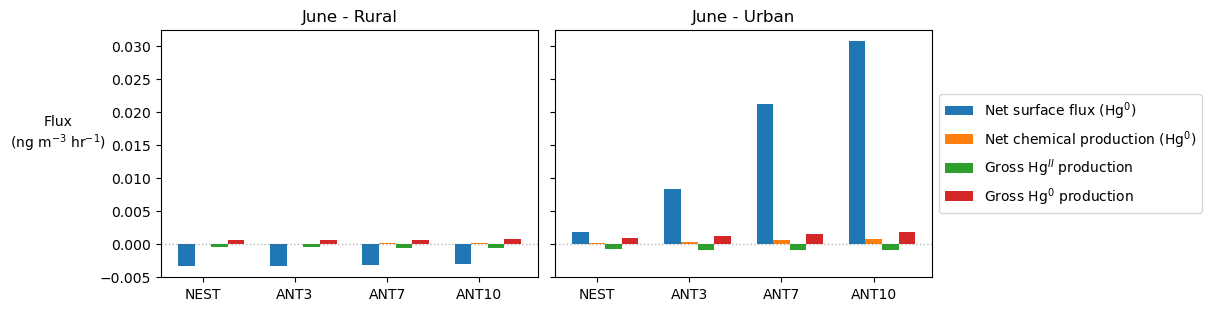

In [73]:
fig,ax=plt.subplots(1,2,figsize=(12,3),sharey=True,layout='constrained')

species = ("NEST", "ANT3", "ANT7",'ANT10')
means = {
    'Net Surface flux (Hg$^{0}$)': (r_f[0]/avg_pbl, r_f3x[0]/avg_pbl, r_f7x[0]/avg_pbl, r_f10x[0]/avg_pbl),
    'Net chemical production (Hg$^{0}$)': (std_r_c['Net_Hg0'].values[0],r_c3x['Net_Hg0'].values[0],r_c7x['Net_Hg0'].values[0],r_c10x['Net_Hg0'].values[0]),
    'Gross Oxidation': (-std_r_c['Prod_Hg2'].values[0],-r_c3x['Prod_Hg2'].values[0],-r_c7x['Prod_Hg2'].values[0],-r_c10x['Prod_Hg2'].values[0]),
    'Gross Reduction': (std_r_c['Prod_Hg0'].values[0],r_c3x['Prod_Hg0'].values[0],r_c7x['Prod_Hg0'].values[0],r_c10x['Prod_Hg0'].values[0])
}

x = np.arange(len(species))  # the label locations
width = 0.18  # the width of the bars
multiplier = 0
for attribute, measurement in means.items():
    offset = width * multiplier
    rects = ax[0].bar(x + offset, measurement, width, label=attribute)
    multiplier += 1
ax[0].set_xticks(x + width, species)
ax[0].set_title('June - Rural')
ax[0].set_ylabel('Flux\n(ng m$^{-3}$ hr$^{-1}$)',rotation=0,labelpad=30)
ax[0].axhline(0,c='dimgray',linestyle=':',alpha=0.5,linewidth=1)

species = ("NEST", "ANT3", "ANT7",'ANT10')
means = {
    'Net surface flux (Hg$^{0}$)': (u_f[0]/avg_pbl, u_f3x[0]/avg_pbl, u_f7x[0]/avg_pbl, u_f10x[0]/avg_pbl),
    'Net chemical production (Hg$^{0}$)': (std_u_c['Net_Hg0'].values[0],u_c3x['Net_Hg0'].values[0],u_c7x['Net_Hg0'].values[0],u_c10x['Net_Hg0'].values[0]),
    'Gross Hg$^{II}$ production': (-std_u_c['Prod_Hg2'].values[0],-u_c3x['Prod_Hg2'].values[0],-u_c7x['Prod_Hg2'].values[0],-u_c10x['Prod_Hg2'].values[0]),
    'Gross Hg$^{0}$ production': (std_u_c['Prod_Hg0'].values[0],u_c3x['Prod_Hg0'].values[0],u_c7x['Prod_Hg0'].values[0],u_c10x['Prod_Hg0'].values[0])
}

x = np.arange(len(species))  # the label locations
width = 0.18  # the width of the bars
multiplier = 0

for attribute, measurement in means.items():
    offset = width * multiplier
    rects = ax[1].bar(x + offset, measurement, width, label=attribute)
    multiplier += 1
ax[1].legend(loc='center left',bbox_to_anchor=(1,0.5))
ax[1].set_xticks(x + width, species)
ax[1].set_title('June - Urban')
ax[1].axhline(0,c='dimgray',linestyle=':',alpha=0.5,linewidth=1)
plt.savefig(figpath+'Supplemental_chemicalcontribution.'+figformat,dpi=dpi,transparent=True)

Need some values for discussion

In [74]:
#rural surface fluxes
rsf = np.array([r_f[0]/avg_pbl, r_f3x[0]/avg_pbl, r_f7x[0]/avg_pbl, r_f10x[0]/avg_pbl])

In [75]:
#rural net chemical fluxes
rcf = np.array([std_r_c['Net_Hg0'].values[0],r_c3x['Net_Hg0'].values[0],r_c7x['Net_Hg0'].values[0],r_c10x['Net_Hg0'].values[0]])

In [76]:
rsf/rcf

array([-808.96283056, -205.72736081,  -80.44616858,  -54.172204  ])

In [77]:
usf = np.array([u_f[0]/avg_pbl, u_f3x[0]/avg_pbl, u_f7x[0]/avg_pbl, u_f10x[0]/avg_pbl])

In [78]:
ucf = np.array([std_u_c['Net_Hg0'].values[0],u_c3x['Net_Hg0'].values[0],u_c7x['Net_Hg0'].values[0],u_c10x['Net_Hg0'].values[0]])

In [79]:
usf/ucf

array([30.84780076, 39.37305429, 41.33232129, 41.74962132])

In [80]:
#now, making the same figure for december

In [81]:
avg_pbl = (merra_hour_d['NJ'].mean()+merra_hour_d['NY'].mean()+merra_hour_d['CT'].mean()+merra_hour_d['NY_us'].mean()+merra_hour_d['VT'].mean())/5

In [82]:
avg_pbl_hPa = z_to_p(avg_pbl)

In [83]:
avg_pbl_hPa

array(944.34258896)

In [84]:
np.where(pprof_rur.values>avg_pbl_hPa)[0]

array([0, 1, 2, 3])

In [85]:
np.where(pprof_urb.values>avg_pbl_hPa)[0]

array([0, 1, 2, 3, 4])

In [86]:
bronx = [-73.8782,40.8680]
nbrunswick = [-74.4226,40.4728]
underhill = [-72.8684,44.5283]
huntington = [-74.2231,43.9731]

In [87]:
#first, reading in the ft, uw concentrations for urban and rural
month = 12

datapath = '../../data/GCdata/GC_processed/'
mstr = str(month).zfill(2)
file = datapath+mstr+'/'

In [88]:
%%capture --no-stdout

def gc_netHg0(file,filename,method='mean'):
    n_f = xr.open_dataset(file+filename)
    n_f['net_ngm2hr'] = n_f['EmisTot_ngm2hr']-n_f['DryDep_Hg0_ngm2hr']

    if method == 'mean':
        r_flux = (((n_f['net_ngm2hr'].sel(lat=underhill[1],lon=underhill[0],method='nearest'))+(n_f['net_ngm2hr'].sel(lat=huntington[1],lon=huntington[0],method='nearest')))/2).values
        u_flux = (((n_f['net_ngm2hr'].sel(lat=bronx[1],lon=bronx[0],method='nearest'))+(n_f['net_ngm2hr'].sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest')))/2).values
        
    if method == 'max':
        r_flux = np.min([n_f['net_ngm2hr'].sel(lat=underhill[1],lon=underhill[0],method='nearest').values,n_f['net_ngm2hr'].sel(lat=huntington[1],lon=huntington[0],method='nearest').values])
        u_flux = np.max([n_f['net_ngm2hr'].sel(lat=bronx[1],lon=bronx[0],method='nearest').values,n_f['net_ngm2hr'].sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').values])

    return r_flux,u_flux

In [89]:
%%capture --no-stdout
r_f,u_f = gc_netHg0(file,'NetHg0Flux_'+mstr+'.nc4')
r_f3x,u_f3x = gc_netHg0(file,'NetHg0Flux_3x_'+mstr+'.nc4')
r_f7x,u_f7x = gc_netHg0(file,'NetHg0Flux_7x_'+mstr+'.nc4')
r_f10x,u_f10x = gc_netHg0(file,'NetHg0Flux_10x_'+mstr+'.nc4')

In [90]:
#06/16/2025: Adding in chemistry flux
def conversion(df):
    return df*100*100*100*3600/(6.022e23)*200.59*1e9

def chem_read(path,loc='urban',levs=0,pbl_level=5):
    '''
    Reading in average chemical flux for month of June accoring to GEOS-Chem
    '''
    
    gc = xr.open_dataset(path)

    if loc=='rural':
        lat=43.976
        lon=-74.206
    if loc=='urban':
        lat=40.898
        lon=-73.903
    
    if levs == 0:
        Hg = gc.isel(lev=0)[['Prod_Hg0','Prod_Hg2']].sel(lat=lat,method='nearest').sel(lon=lon,method='nearest').to_dataframe()

        Hg['Prod_Hg0'] = conversion(Hg['Prod_Hg0'])
        Hg['Prod_Hg2'] = conversion(Hg['Prod_Hg2'])
        Hg['Net_Hg0'] = Hg['Prod_Hg0']-Hg['Prod_Hg2']

    if levs == 'pbl_level':    
        Hg = gc.isel(lev=slice(0,pbl_level))[['Prod_Hg0','Prod_Hg2']].sel(lat=lat,method='nearest').sel(lon=lon,method='nearest').mean('lev').to_dataframe()

        Hg['Prod_Hg0'] = conversion(Hg['Prod_Hg0'])
        Hg['Prod_Hg2'] = conversion(Hg['Prod_Hg2'])
        Hg['Net_Hg0'] = Hg['Prod_Hg0']-Hg['Prod_Hg2']

    if levs == 'all':
        Hg = gc.sel(lat=lat,method='nearest').sel(lon=lon,method='nearest')

        Hg['Net_Hg0'] = Hg['Prod_Hg0']-Hg['Prod_Hg2']
        

    #Hg = Hg.shift(-4)

    #Hg['hour'] = Hg.index.hour
    #Hg = Hg.groupby('hour').mean()

    return Hg


In [91]:
path_std = '/net/fs03/d0/emroy/GCrundir/run0051/OutputDir/GEOSChem.ProdLoss.2019'+str(month).zfill(2)+'01_0000z.nc4'
path_3x = '/net/fs03/d0/emroy/GCrundir/run0052/OutputDir/GEOSChem.ProdLoss.2019'+str(month).zfill(2)+'01_0000z.nc4'
path_7x = '/net/fs03/d0/emroy/GCrundir/run0054/OutputDir/GEOSChem.ProdLoss.2019'+str(month).zfill(2)+'01_0000z.nc4'
path_10x = '/net/fs03/d0/emroy/GCrundir/run0053/OutputDir/GEOSChem.ProdLoss.2019'+str(month).zfill(2)+'01_0000z.nc4'

In [92]:
%%capture --no-stdout

std_r_c = chem_read(path_std,loc='rural',levs='pbl_level')
r_c3x = chem_read(path_3x,loc='rural',levs='pbl_level')
r_c7x = chem_read(path_7x,loc='rural',levs='pbl_level')
r_c10x = chem_read(path_10x,loc='rural',levs='pbl_level')

std_u_c = chem_read(path_std,loc='urban',levs='pbl_level')
u_c3x = chem_read(path_3x,loc='urban',levs='pbl_level')
u_c7x = chem_read(path_7x,loc='urban',levs='pbl_level')
u_c10x = chem_read(path_10x,loc='urban',levs='pbl_level')

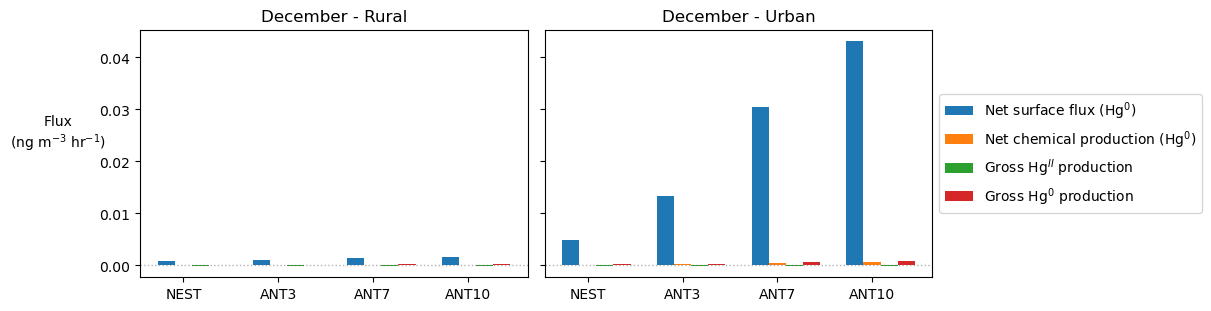

In [93]:
fig,ax=plt.subplots(1,2,figsize=(12,3),sharey=True,layout='constrained')

species = ("NEST", "ANT3", "ANT7",'ANT10')
means = {
    'Net Surface flux (Hg$^{0}$)': (r_f[0]/avg_pbl, r_f3x[0]/avg_pbl, r_f7x[0]/avg_pbl, r_f10x[0]/avg_pbl),
    'Net chemical production (Hg$^{0}$)': (std_r_c['Net_Hg0'].values[0],r_c3x['Net_Hg0'].values[0],r_c7x['Net_Hg0'].values[0],r_c10x['Net_Hg0'].values[0]),
    'Gross Oxidation': (-std_r_c['Prod_Hg2'].values[0],-r_c3x['Prod_Hg2'].values[0],-r_c7x['Prod_Hg2'].values[0],-r_c10x['Prod_Hg2'].values[0]),
    'Gross Reduction': (std_r_c['Prod_Hg0'].values[0],r_c3x['Prod_Hg0'].values[0],r_c7x['Prod_Hg0'].values[0],r_c10x['Prod_Hg0'].values[0])
}

x = np.arange(len(species))  # the label locations
width = 0.18  # the width of the bars
multiplier = 0
for attribute, measurement in means.items():
    offset = width * multiplier
    rects = ax[0].bar(x + offset, measurement, width, label=attribute)
    multiplier += 1
ax[0].set_xticks(x + width, species)
ax[0].set_title('December - Rural')
ax[0].set_ylabel('Flux\n(ng m$^{-3}$ hr$^{-1}$)',rotation=0,labelpad=30)
ax[0].axhline(0,c='dimgray',linestyle=':',alpha=0.5,linewidth=1)

species = ("NEST", "ANT3", "ANT7",'ANT10')
means = {
    'Net surface flux (Hg$^{0}$)': (u_f[0]/avg_pbl, u_f3x[0]/avg_pbl, u_f7x[0]/avg_pbl, u_f10x[0]/avg_pbl),
    'Net chemical production (Hg$^{0}$)': (std_u_c['Net_Hg0'].values[0],u_c3x['Net_Hg0'].values[0],u_c7x['Net_Hg0'].values[0],u_c10x['Net_Hg0'].values[0]),
    'Gross Hg$^{II}$ production': (-std_u_c['Prod_Hg2'].values[0],-u_c3x['Prod_Hg2'].values[0],-u_c7x['Prod_Hg2'].values[0],-u_c10x['Prod_Hg2'].values[0]),
    'Gross Hg$^{0}$ production': (std_u_c['Prod_Hg0'].values[0],u_c3x['Prod_Hg0'].values[0],u_c7x['Prod_Hg0'].values[0],u_c10x['Prod_Hg0'].values[0])
}

x = np.arange(len(species))  # the label locations
width = 0.18  # the width of the bars
multiplier = 0

for attribute, measurement in means.items():
    offset = width * multiplier
    rects = ax[1].bar(x + offset, measurement, width, label=attribute)
    multiplier += 1
ax[1].legend(loc='center left',bbox_to_anchor=(1,0.5))
ax[1].set_xticks(x + width, species)
ax[1].set_title('December - Urban')
ax[1].axhline(0,c='dimgray',linestyle=':',alpha=0.5,linewidth=1)
plt.savefig(figpath+'Supplemental_chemicalcontribution_dec.'+figformat,dpi=dpi,transparent=True)

**Supplemental Section 5**  
Plot to show that the diel variation of Hg at Elizabeth, NJ is largely incoherent, indicative of hyper-local sources

In [94]:
bronx = [-73.8782,40.8680]
nbrunswick = [-74.4226,40.4728]
underhill = [-72.8684,44.5283]
huntington = [-74.2231,43.9731]

In [95]:
%%capture --no-stdout

### Reading in NADP data ###

Amnet=pd.read_csv('../../data/NADP/AMNET-NE-h.csv',na_values=(-9))
Amnet['collStart'] = pd.to_datetime(Amnet['collStart'])
Amnet['collEnd'] = pd.to_datetime(Amnet['collEnd'])
Amnet = Amnet.set_index('collStart')

#subsetting sites of interest
start = '2011-01-01'#'2014-01-01'
end = '2020-01-01'

Amnet = Amnet[Amnet.index>start]
Amnet = Amnet[Amnet.index<end]
Amnet_all = Amnet.copy()
Amnet['hour'] = Amnet.index.hour 

Amnet_jja = Amnet[Amnet.index.month>=6]
Amnet_jja = Amnet_jja[Amnet_jja.index.month<=8]

Amnet_djf = Amnet[(Amnet.index.month==12) | (Amnet.index.month<=2) ]

Amnet_j = Amnet[Amnet.index.month==6]
Amnet_d = Amnet[Amnet.index.month==12]

#Amnet = Amnet[Amnet.index.month>=6]
#Amnet = Amnet[Amnet.index.month<=8]

NJ54_jja = Amnet_jja[Amnet_jja['SiteID']=='NJ54'].groupby('hour').mean()
NJ30_jja = Amnet_jja[Amnet_jja['SiteID']=='NJ30'].groupby('hour').mean()
NY06_jja = Amnet_jja[Amnet_jja['SiteID']=='NY06'].groupby('hour').mean()
NY20_jja = Amnet_jja[Amnet_jja['SiteID']=='NY20'].groupby('hour').mean()
VT99_jja = Amnet_jja[Amnet_jja['SiteID']=='VT99'].groupby('hour').mean()
MD08_jja = Amnet_jja[Amnet_jja['SiteID']=='MD08'].groupby('hour').mean()
MD99_jja = Amnet_jja[Amnet_jja['SiteID']=='MD98'].groupby('hour').mean()
NJ05_jja = Amnet_jja[Amnet_jja['SiteID']=='NJ05'].groupby('hour').mean()

NJ54_djf = Amnet_djf[Amnet_djf['SiteID']=='NJ54'].groupby('hour').mean()
NJ30_djf = Amnet_djf[Amnet_djf['SiteID']=='NJ30'].groupby('hour').mean()
NY06_djf = Amnet_djf[Amnet_djf['SiteID']=='NY06'].groupby('hour').mean()
NY20_djf = Amnet_djf[Amnet_djf['SiteID']=='NY20'].groupby('hour').mean()
VT99_djf = Amnet_djf[Amnet_djf['SiteID']=='VT99'].groupby('hour').mean()
MD08_djf = Amnet_djf[Amnet_djf['SiteID']=='MD08'].groupby('hour').mean()
MD99_djf = Amnet_djf[Amnet_djf['SiteID']=='MD98'].groupby('hour').mean()
NJ05_djf = Amnet_djf[Amnet_djf['SiteID']=='NJ05'].groupby('hour').mean()

NJ54_j = Amnet_j[Amnet_j['SiteID']=='NJ54'].groupby('hour').mean()
NJ30_j = Amnet_j[Amnet_j['SiteID']=='NJ30'].groupby('hour').mean()
NY06_j = Amnet_j[Amnet_j['SiteID']=='NY06'].groupby('hour').mean()
NY20_j = Amnet_j[Amnet_j['SiteID']=='NY20'].groupby('hour').mean()
VT99_j = Amnet_j[Amnet_j['SiteID']=='VT99'].groupby('hour').mean()
MD08_j = Amnet_j[Amnet_j['SiteID']=='MD08'].groupby('hour').mean()
MD99_j = Amnet_j[Amnet_j['SiteID']=='MD98'].groupby('hour').mean()
NJ05_j = Amnet_j[Amnet_j['SiteID']=='NJ05'].groupby('hour').mean()

NJ54_d = Amnet_d[Amnet_d['SiteID']=='NJ54'].groupby('hour').mean()
NJ30_d = Amnet_d[Amnet_d['SiteID']=='NJ30'].groupby('hour').mean()
NY06_d = Amnet_d[Amnet_d['SiteID']=='NY06'].groupby('hour').mean()
NY20_d = Amnet_d[Amnet_d['SiteID']=='NY20'].groupby('hour').mean()
VT99_d = Amnet_d[Amnet_d['SiteID']=='VT99'].groupby('hour').mean()
MD08_d = Amnet_d[Amnet_d['SiteID']=='MD08'].groupby('hour').mean()
MD99_d = Amnet_d[Amnet_d['SiteID']=='MD98'].groupby('hour').mean()
NJ05_d = Amnet_d[Amnet_d['SiteID']=='NJ05'].groupby('hour').mean()

NJ54_h = Amnet_all[Amnet_all['SiteID']=='NJ54']
NJ30_h = Amnet_all[Amnet_all['SiteID']=='NJ30']
NY06_h = Amnet_all[Amnet_all['SiteID']=='NY06']
NY20_h = Amnet_all[Amnet_all['SiteID']=='NY20']
VT99_h = Amnet_all[Amnet_all['SiteID']=='VT99']

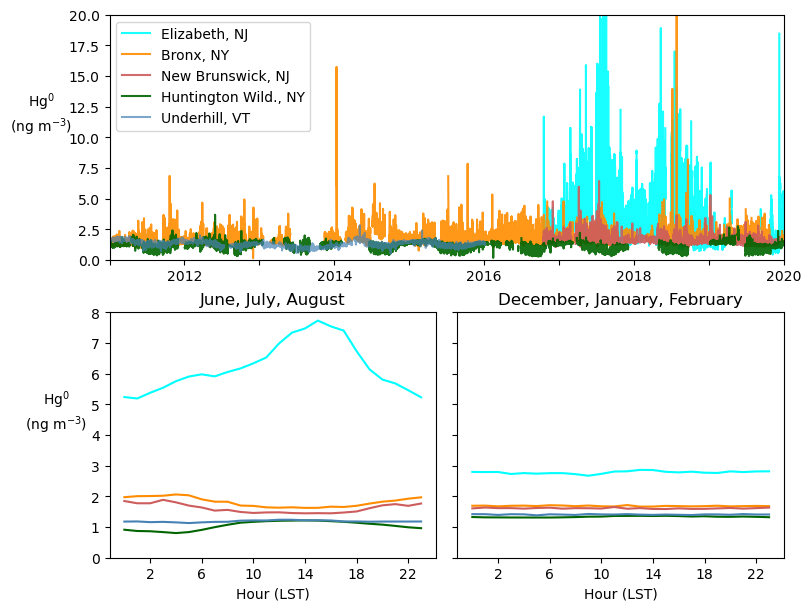

In [96]:
fig, ax_dict = plt.subplot_mosaic([['top_panel', 'top_panel'],
                                   ['bottom_left', 'bottom_right']],
                                  figsize=(8, 6),layout='constrained')

# Access the axes by their names
ax_top = ax_dict['top_panel']
ax_bottom_left = ax_dict['bottom_left']
ax_bottom_right = ax_dict['bottom_right']

ax_top.plot(NJ54_h.index,NJ54_h['GEM'],c='aqua',alpha=0.9,label='Elizabeth, NJ')
ax_top.plot(NY06_h.index,NY06_h['GEM'],c='darkorange',alpha=0.9,label='Bronx, NY')
ax_top.plot(NJ30_h.index,NJ30_h['GEM'],c='indianred',alpha=0.9,label='New Brunswick, NJ')
ax_top.plot(NY20_h.index,NY20_h['GEM'],c='darkgreen',alpha=0.9,label='Huntington Wild., NY')
ax_top.plot(VT99_h.index,VT99_h['GEM'],c='steelblue',alpha=0.7,label='Underhill, VT')

ax_top.set_ylim(0,20)

ax_bottom_left.plot(NY20_jja['GEM'],c='darkgreen')
ax_bottom_left.plot(VT99_jja['GEM'],c='steelblue')
ax_bottom_left.plot(NJ54_jja['GEM'],c='aqua')
ax_bottom_left.plot(NY06_jja['GEM'],c='darkorange')
ax_bottom_left.plot(NJ30_jja['GEM'],c='indianred')

#adding fill between
ax_bottom_right.plot(NY20_djf['GEM'],c='darkgreen')
ax_bottom_right.plot(VT99_djf['GEM'],c='steelblue')
ax_bottom_right.plot(NJ54_djf['GEM'],c='aqua')
ax_bottom_right.plot(NY06_djf['GEM'],c='darkorange')
ax_bottom_right.plot(NJ30_djf['GEM'],c='indianred')

ax_top.legend()
ax_top.set_xlim(pd.to_datetime('2011'),pd.to_datetime('2020'))
ax_top.set_xticks(['2011','2012','2013','2014','2015','2016','2017','2018','2019','2020'])
ax_top.set_xticklabels(['','2012','','2014','','2016','','2018','','2020'])


ax_bottom_left.set_title('June, July, August')
ax_bottom_right.set_title('December, January, February')

ax_bottom_left.set_ylim(0,8)
ax_bottom_right.set_ylim(0,8)

ax_bottom_left.set_xticks([2,6,10,14,18,22])
ax_bottom_right.set_xticks([2,6,10,14,18,22])
ax_bottom_left.set_xlabel('Hour (LST)')
ax_bottom_right.set_xlabel('Hour (LST)')

ax_top.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=20)
ax_bottom_left.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=25)
ax_bottom_right.axes.yaxis.set_ticklabels([])

plt.savefig(figpath+'Supplemental_ElizabethPlot_JJA.'+figformat,dpi=dpi,transparent=True)

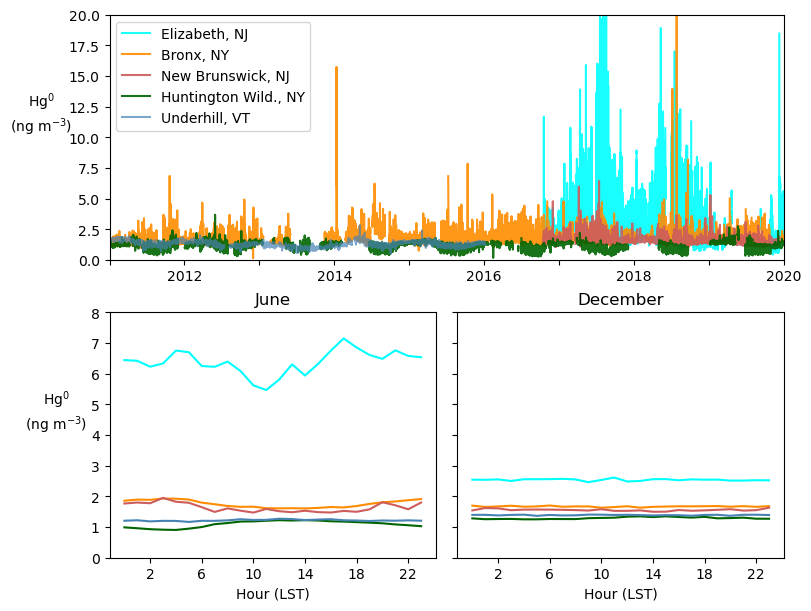

In [97]:
fig, ax_dict = plt.subplot_mosaic([['top_panel', 'top_panel'],
                                   ['bottom_left', 'bottom_right']],
                                  figsize=(8, 6),layout='constrained')

# Access the axes by their names
ax_top = ax_dict['top_panel']
ax_bottom_left = ax_dict['bottom_left']
ax_bottom_right = ax_dict['bottom_right']

ax_top.plot(NJ54_h.index,NJ54_h['GEM'],c='aqua',alpha=0.9,label='Elizabeth, NJ')
ax_top.plot(NY06_h.index,NY06_h['GEM'],c='darkorange',alpha=0.9,label='Bronx, NY')
ax_top.plot(NJ30_h.index,NJ30_h['GEM'],c='indianred',alpha=0.9,label='New Brunswick, NJ')
ax_top.plot(NY20_h.index,NY20_h['GEM'],c='darkgreen',alpha=0.9,label='Huntington Wild., NY')
ax_top.plot(VT99_h.index,VT99_h['GEM'],c='steelblue',alpha=0.7,label='Underhill, VT')

ax_top.set_ylim(0,20)

ax_bottom_left.plot(NY20_j['GEM'],c='darkgreen')
ax_bottom_left.plot(VT99_j['GEM'],c='steelblue')
ax_bottom_left.plot(NJ54_j['GEM'],c='aqua')
ax_bottom_left.plot(NY06_j['GEM'],c='darkorange')
ax_bottom_left.plot(NJ30_j['GEM'],c='indianred')

#adding fill between
ax_bottom_right.plot(NY20_d['GEM'],c='darkgreen')
ax_bottom_right.plot(VT99_d['GEM'],c='steelblue')
ax_bottom_right.plot(NJ54_d['GEM'],c='aqua')
ax_bottom_right.plot(NY06_d['GEM'],c='darkorange')
ax_bottom_right.plot(NJ30_d['GEM'],c='indianred')

ax_top.legend()
ax_top.set_xlim(pd.to_datetime('2011'),pd.to_datetime('2020'))
ax_top.set_xticks(['2011','2012','2013','2014','2015','2016','2017','2018','2019','2020'])
ax_top.set_xticklabels(['','2012','','2014','','2016','','2018','','2020'])

ax_bottom_left.set_title('June')
ax_bottom_right.set_title('December')

#ax_bottom_left.set_title('June, July, August')
#ax_bottom_right.set_title('December, January, February')

ax_bottom_left.set_ylim(0,8)
ax_bottom_right.set_ylim(0,8)

ax_bottom_left.set_xticks([2,6,10,14,18,22])
ax_bottom_right.set_xticks([2,6,10,14,18,22])
ax_bottom_left.set_xlabel('Hour (LST)')
ax_bottom_right.set_xlabel('Hour (LST)')

ax_top.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=20)
ax_bottom_left.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=25)
ax_bottom_right.axes.yaxis.set_ticklabels([])

plt.savefig(figpath+'Supplemental_ElizabethPlot_J.'+figformat,dpi=dpi,transparent=True)

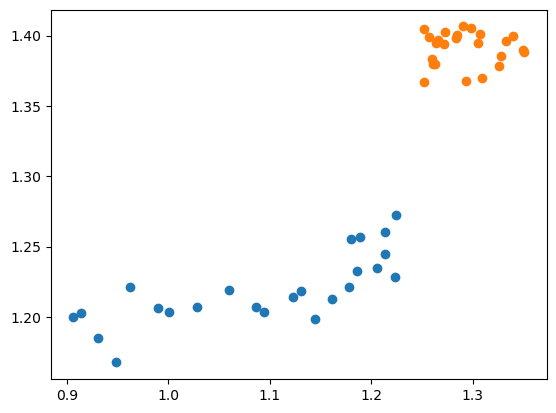

In [104]:
plt.scatter(NY20_j['GEM'],VT99_j['GEM'])
plt.scatter(NY20_d['GEM'],VT99_d['GEM'])

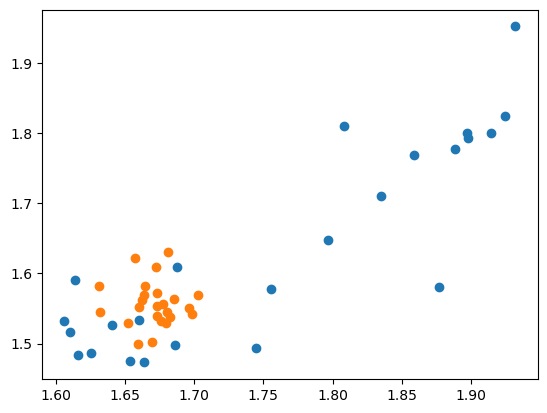

In [105]:
plt.scatter(NY06_j['GEM'],NJ30_j['GEM'])
plt.scatter(NY06_d['GEM'],NJ30_d['GEM'])

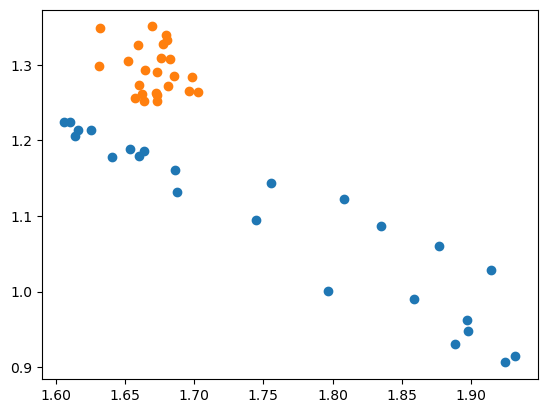

In [106]:
plt.scatter(NY06_j['GEM'],NY20_j['GEM'])
plt.scatter(NY06_d['GEM'],NY20_d['GEM'])

**Supplemental Section 6**  
Plot to show that the 

In [8]:
#user inputs
year = 2019
month = 6

bronx = [-73.8782,40.8680]
nbrunswick = [-74.4226,40.4728]
underhill = [-72.8684,44.5283]
huntington = [-74.2231,43.9731]

In [9]:
#defining the 1976 std atmosphere (using values from S&P)
p_stdatm = np.array([1013,898,795,701.2,616.6,540.5,472.2,411.1,356.5,308,265,227,194,165,142,121,103,88.5,75.6,64.6,5.53]) #converts from hPa to Pa
T_stdatm = np.array([288,282,275,269,262,256,249,243,236,230,223,217,217,217,217,217,217,217,217,217,217]) #K
z_stdatm = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])*1000 #m

p_to_z = interp1d(p_stdatm,z_stdatm,fill_value='extrapolate')
z_to_p = interp1d(z_stdatm,p_stdatm,fill_value='extrapolate')

#p_to_z(1012)

In [10]:
#reading in necessary met (using 2x2.5 for efficiency, nested makes little difference when aggregated across region)
met = xr.open_dataset('../../data/pblh/MERRA2/MERRA2.'+str(year)+str(month).zfill(2)+'.pblh.2x25.nc4')

In [11]:
path = '../../data/GCdata/GC_output/'
file = '/GEOSChem.SpeciesConcHF.'+str(year)+str(month).zfill(2)+'01_0000z.nc4'

base_s = xr.open_mfdataset(path+'STND'+file).load()
base_n = xr.open_mfdataset(path+'NEST'+file).load()
base_n_7x_nescale = xr.open_mfdataset(path+'ANT7'+file).load()
base_n_FTscale_t = xr.open_mfdataset(path+'CFTSCAL'+file).load()


In [12]:
%%capture --no-stdout

#calculating pressure at each gridbox
p_i = base_s['hyai']+(base_s['hybi']*(met['SLP'])/100)
p_m = p_i.rolling(ilev=2).mean().dropna('ilev')
p_m = p_m.assign_coords(ilev=(base_s.lev.values))
p_m = p_m.rename({'ilev':'lev'})
p_m = p_m.sel(lat=base_s['lat'],lon=base_s['lon']).resample(time='1H').mean()
base_s = xr.merge([base_s,p_m.to_dataset(name='P_m')])

In [13]:
pblh_rural = met['PBLH'].sel(lon=huntington[0],lat=huntington[1],method='nearest')
pblh_urban = met['PBLH'].sel(lon=nbrunswick[0],lat=nbrunswick[1],method='nearest')

pblp_rural = z_to_p(pblh_rural.values)
pblp_urban = z_to_p(pblh_urban.values)

/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise 

In [14]:
test_pressure = base_s.mean(('time','lat','lon'))['P_m']

In [15]:
urban_anchor = [39.75,-76.6]
rural_anchor = [42.25,-76.6]
lat_extent = 1.5
lon_extent = 1.875

In [16]:
land = 'white'
water = '#7294b8'#'steelblue'#'lightslategrey'
boarder = 'black'

states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none')

In [17]:
#This is the standard run

/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


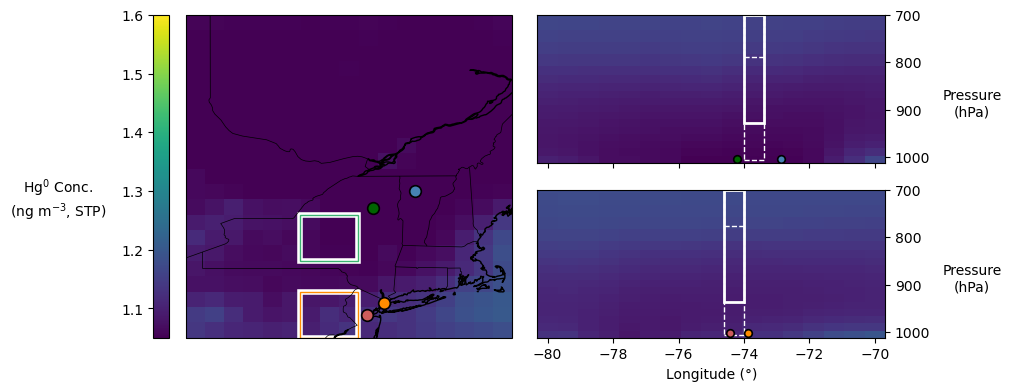

In [18]:
#key settings
vmin=1.05
vmax=1.6

ds = base_n

data=f.HgConversion(ds['SpeciesConcVV_Hg0'].mean('time').isel(lev=0))

fig, ax_dict = plt.subplot_mosaic([['left', 'top_right'],
                                   ['left', 'bottom_right']],
                                  figsize=(10,3.8),
                                  layout='constrained',
                                  sharex=True,
                                  )

ax_left = ax_dict['left']
ax_top_right = ax_dict['top_right']
ax_bottom_right = ax_dict['bottom_right']

ss = ax_left.get_subplotspec()
ax_left.remove()

ax_left = fig.add_subplot(ss, projection=ccrs.PlateCarree())
g = ax_left.pcolormesh(data.lon,data.lat,data,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True)
ax_left.add_feature(cfeature.COASTLINE,zorder=10)
ax_left.add_feature(cfeature.BORDERS,color=boarder,linewidth=0.5)
ax_left.add_feature(states_provinces,linewidth=0.5,zorder=10,edgecolor='black')

#urban uw box
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='darkorange',
                                transform=ccrs.PlateCarree(),linewidth=1))
#Rural uw box
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='mediumseagreen',
                                transform=ccrs.PlateCarree(),linewidth=1))

cbar = fig.colorbar(g,cax=ax_left.inset_axes([-0.1, 0, 0.05, 1]))
cbar.ax.yaxis.set_ticks_position('left')
cbar.set_label('Hg$^{0}$ Conc.\n(ng m$^{-3}$, STP)',rotation=0,labelpad=-80)
#cbar = fig.colorbar(g, orientation='horizontal',cax=ax_left.inset_axes([0, -0.07, 1, 0.05]))
#cbar.set_label('Hg$^{0}$ Concentration (ng m$^{-3}$, STP)')

#measurement sites
ax_left.scatter(bronx[0],bronx[1],marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_left.scatter(nbrunswick[0],nbrunswick[1],marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_left.scatter(underhill[0],underhill[1],marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_left.scatter(huntington[0],huntington[1],marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')

#now, adding the vertical cross section (urban)
urban_cs = ds.sel(lat=slice(urban_anchor[0],urban_anchor[0]+lat_extent))
urban_cs = f.HgConversion(urban_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_bottom_right.pcolormesh(urban_cs.lon,test_pressure,urban_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_bottom_right.set_ylim(700,1012)
ax_bottom_right.invert_yaxis()
ax_bottom_right.yaxis.tick_right()

ax_bottom_right.scatter(bronx[0],1003,marker='o',c='darkorange',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_bottom_right.scatter(nbrunswick[0],1003,marker='o',c='indianred',s=30,zorder=30,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
#ax_bottom_right.scatter(underhill[0],990,marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
#ax_bottom_right.scatter(huntington[0],990,marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_bottom_right.set_xlabel('Longitude (°)')
ax_bottom_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_bottom_right.yaxis.set_label_position('right')

#now, adding the vertical cross section (rural)
rural_cs = ds.sel(lat=slice(rural_anchor[0],rural_anchor[0]+lat_extent))
rural_cs = f.HgConversion(rural_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_top_right.pcolormesh(rural_cs.lon,test_pressure,rural_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_top_right.set_ylim(700,1012)
ax_top_right.invert_yaxis()
ax_top_right.yaxis.tick_right()

#ax_top_right.scatter(bronx[0],990,marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
#ax_top_right.scatter(nbrunswick[0],990,marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_top_right.scatter(underhill[0],1005,marker='o',c='steelblue',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_top_right.scatter(huntington[0],1005,marker='o',c='darkgreen',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_top_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_top_right.yaxis.set_label_position('right')

#now drawing boxes over areas used to calculate geoschem parameters
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.min()], width=0.625, height=700-pblp_rural.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.max()], width=0.625, height=700-pblp_rural.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.mean()], width=0.625, height=700-pblp_rural.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.min()], width=0.625, height=700-pblp_urban.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.max()], width=0.625, height=700-pblp_urban.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.mean()], width=0.625, height=700-pblp_urban.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

plt.savefig(figpath+'Supplemental_CUW_CFT_J_std.'+figformat,dpi=dpi,transparent=True)

In [19]:
#This is the 7x ne scale

/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


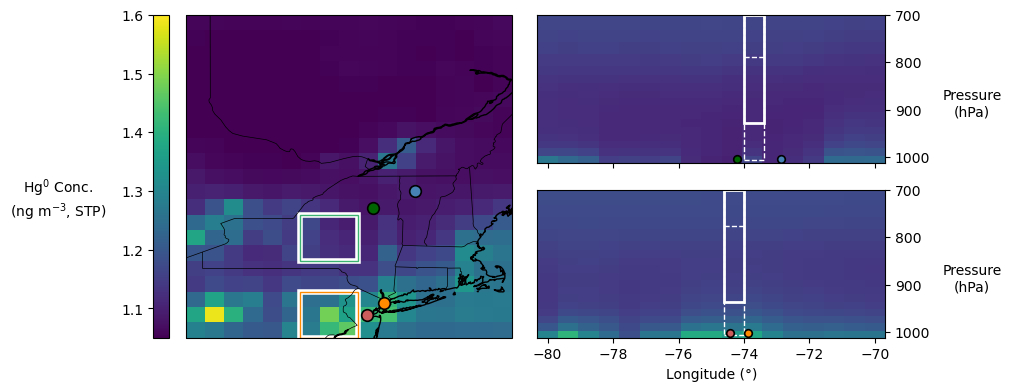

In [20]:
#key settings
vmin=1.05
vmax=1.6

ds = base_n_7x_nescale

data=f.HgConversion(ds['SpeciesConcVV_Hg0'].mean('time').isel(lev=0))

fig, ax_dict = plt.subplot_mosaic([['left', 'top_right'],
                                   ['left', 'bottom_right']],
                                  figsize=(10,3.8),
                                  layout='constrained',
                                  sharex=True,
                                  )

ax_left = ax_dict['left']
ax_top_right = ax_dict['top_right']
ax_bottom_right = ax_dict['bottom_right']

ss = ax_left.get_subplotspec()
ax_left.remove()

ax_left = fig.add_subplot(ss, projection=ccrs.PlateCarree())
g = ax_left.pcolormesh(data.lon,data.lat,data,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True)
ax_left.add_feature(cfeature.COASTLINE,zorder=10)
ax_left.add_feature(cfeature.BORDERS,color=boarder,linewidth=0.5)
ax_left.add_feature(states_provinces,linewidth=0.5,zorder=10,edgecolor='black')

#urban uw box
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='darkorange',
                                transform=ccrs.PlateCarree(),linewidth=1))
#Rural uw box
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='mediumseagreen',
                                transform=ccrs.PlateCarree(),linewidth=1))

cbar = fig.colorbar(g,cax=ax_left.inset_axes([-0.1, 0, 0.05, 1]))
cbar.ax.yaxis.set_ticks_position('left')
cbar.set_label('Hg$^{0}$ Conc.\n(ng m$^{-3}$, STP)',rotation=0,labelpad=-80)
#cbar = fig.colorbar(g, orientation='horizontal',cax=ax_left.inset_axes([0, -0.07, 1, 0.05]))
#cbar.set_label('Hg$^{0}$ Concentration (ng m$^{-3}$, STP)')

#measurement sites
ax_left.scatter(bronx[0],bronx[1],marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_left.scatter(nbrunswick[0],nbrunswick[1],marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_left.scatter(underhill[0],underhill[1],marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_left.scatter(huntington[0],huntington[1],marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')

#now, adding the vertical cross section (urban)
urban_cs = ds.sel(lat=slice(urban_anchor[0],urban_anchor[0]+lat_extent))
urban_cs = f.HgConversion(urban_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_bottom_right.pcolormesh(urban_cs.lon,test_pressure,urban_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_bottom_right.set_ylim(700,1012)
ax_bottom_right.invert_yaxis()
ax_bottom_right.yaxis.tick_right()

ax_bottom_right.scatter(bronx[0],1003,marker='o',c='darkorange',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_bottom_right.scatter(nbrunswick[0],1003,marker='o',c='indianred',s=30,zorder=30,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
#ax_bottom_right.scatter(underhill[0],990,marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
#ax_bottom_right.scatter(huntington[0],990,marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_bottom_right.set_xlabel('Longitude (°)')
ax_bottom_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_bottom_right.yaxis.set_label_position('right')

#now, adding the vertical cross section (rural)
rural_cs = ds.sel(lat=slice(rural_anchor[0],rural_anchor[0]+lat_extent))
rural_cs = f.HgConversion(rural_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_top_right.pcolormesh(rural_cs.lon,test_pressure,rural_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_top_right.set_ylim(700,1012)
ax_top_right.invert_yaxis()
ax_top_right.yaxis.tick_right()

#ax_top_right.scatter(bronx[0],990,marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
#ax_top_right.scatter(nbrunswick[0],990,marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_top_right.scatter(underhill[0],1005,marker='o',c='steelblue',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_top_right.scatter(huntington[0],1005,marker='o',c='darkgreen',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_top_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_top_right.yaxis.set_label_position('right')

#now drawing boxes over areas used to calculate geoschem parameters
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.min()], width=0.625, height=700-pblp_rural.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.max()], width=0.625, height=700-pblp_rural.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.mean()], width=0.625, height=700-pblp_rural.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.min()], width=0.625, height=700-pblp_urban.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.max()], width=0.625, height=700-pblp_urban.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.mean()], width=0.625, height=700-pblp_urban.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

plt.savefig(figpath+'Supplemental_CUW_CFT_J_7xnes.'+figformat,dpi=dpi,transparent=True)

/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


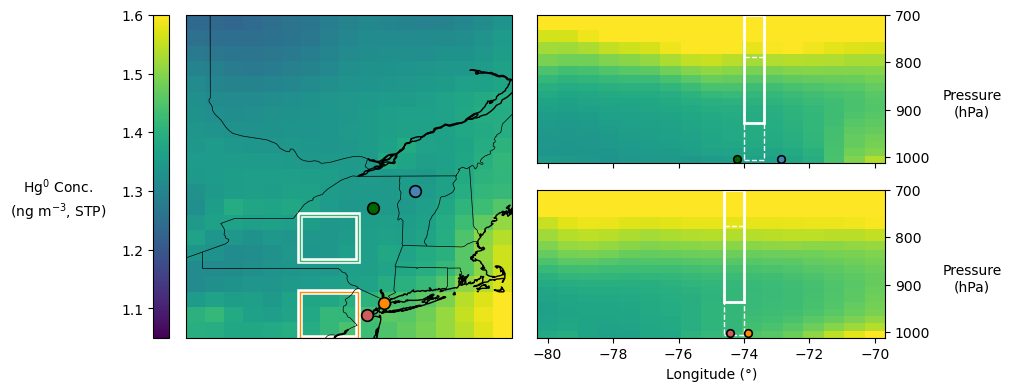

In [21]:
#key settings
vmin=1.05
vmax=1.6

ds = base_n_FTscale_t

data=f.HgConversion(ds['SpeciesConcVV_Hg0'].mean('time').isel(lev=0))

fig, ax_dict = plt.subplot_mosaic([['left', 'top_right'],
                                   ['left', 'bottom_right']],
                                  figsize=(10,3.8),
                                  layout='constrained',
                                  sharex=True,
                                  )

ax_left = ax_dict['left']
ax_top_right = ax_dict['top_right']
ax_bottom_right = ax_dict['bottom_right']

ss = ax_left.get_subplotspec()
ax_left.remove()

ax_left = fig.add_subplot(ss, projection=ccrs.PlateCarree())
g = ax_left.pcolormesh(data.lon,data.lat,data,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True)
ax_left.add_feature(cfeature.COASTLINE,zorder=10)
ax_left.add_feature(cfeature.BORDERS,color=boarder,linewidth=0.5)
ax_left.add_feature(states_provinces,linewidth=0.5,zorder=10,edgecolor='black')

#urban uw box
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='darkorange',
                                transform=ccrs.PlateCarree(),linewidth=1))
#Rural uw box
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='mediumseagreen',
                                transform=ccrs.PlateCarree(),linewidth=1))

cbar = fig.colorbar(g,cax=ax_left.inset_axes([-0.1, 0, 0.05, 1]))
cbar.ax.yaxis.set_ticks_position('left')
cbar.set_label('Hg$^{0}$ Conc.\n(ng m$^{-3}$, STP)',rotation=0,labelpad=-80)
#cbar = fig.colorbar(g, orientation='horizontal',cax=ax_left.inset_axes([0, -0.07, 1, 0.05]))
#cbar.set_label('Hg$^{0}$ Concentration (ng m$^{-3}$, STP)')

#measurement sites
ax_left.scatter(bronx[0],bronx[1],marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_left.scatter(nbrunswick[0],nbrunswick[1],marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_left.scatter(underhill[0],underhill[1],marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_left.scatter(huntington[0],huntington[1],marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')

#now, adding the vertical cross section (urban)
urban_cs = ds.sel(lat=slice(urban_anchor[0],urban_anchor[0]+lat_extent))
urban_cs = f.HgConversion(urban_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_bottom_right.pcolormesh(urban_cs.lon,test_pressure,urban_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_bottom_right.set_ylim(700,1012)
ax_bottom_right.invert_yaxis()
ax_bottom_right.yaxis.tick_right()

ax_bottom_right.scatter(bronx[0],1003,marker='o',c='darkorange',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_bottom_right.scatter(nbrunswick[0],1003,marker='o',c='indianred',s=30,zorder=30,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
#ax_bottom_right.scatter(underhill[0],990,marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
#ax_bottom_right.scatter(huntington[0],990,marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_bottom_right.set_xlabel('Longitude (°)')
ax_bottom_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_bottom_right.yaxis.set_label_position('right')

#now, adding the vertical cross section (rural)
rural_cs = ds.sel(lat=slice(rural_anchor[0],rural_anchor[0]+lat_extent))
rural_cs = f.HgConversion(rural_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_top_right.pcolormesh(rural_cs.lon,test_pressure,rural_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_top_right.set_ylim(700,1012)
ax_top_right.invert_yaxis()
ax_top_right.yaxis.tick_right()

#ax_top_right.scatter(bronx[0],990,marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
#ax_top_right.scatter(nbrunswick[0],990,marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_top_right.scatter(underhill[0],1005,marker='o',c='steelblue',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_top_right.scatter(huntington[0],1005,marker='o',c='darkgreen',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_top_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_top_right.yaxis.set_label_position('right')

#now drawing boxes over areas used to calculate geoschem parameters
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.min()], width=0.625, height=700-pblp_rural.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.max()], width=0.625, height=700-pblp_rural.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.mean()], width=0.625, height=700-pblp_rural.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.min()], width=0.625, height=700-pblp_urban.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.max()], width=0.625, height=700-pblp_urban.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.mean()], width=0.625, height=700-pblp_urban.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

plt.savefig(figpath+'Supplemental_CUW_CFT_J_FTtuned.'+figformat,dpi=dpi,transparent=True)

In [8]:
#now lets do the same thing for December!

In [9]:
#user inputs
year = 2019
month = 12

datapath = '/home/emroy/RegionalBoxModel/data/GEOSChem/'

bronx = [-73.8782,40.8680]
nbrunswick = [-74.4226,40.4728]
underhill = [-72.8684,44.5283]
huntington = [-74.2231,43.9731]

In [10]:
#defining the 1976 std atmosphere (using values from S&P)
p_stdatm = np.array([1013,898,795,701.2,616.6,540.5,472.2,411.1,356.5,308,265,227,194,165,142,121,103,88.5,75.6,64.6,5.53]) #converts from hPa to Pa
T_stdatm = np.array([288,282,275,269,262,256,249,243,236,230,223,217,217,217,217,217,217,217,217,217,217]) #K
z_stdatm = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])*1000 #m

p_to_z = interp1d(p_stdatm,z_stdatm,fill_value='extrapolate')
z_to_p = interp1d(z_stdatm,p_stdatm,fill_value='extrapolate')

#p_to_z(1012)

In [11]:
#reading in necessary met (using 2x2.5 for efficiency, nested makes little difference when aggregated across region)
met = xr.open_dataset('/home/emroy/RegionalBoxModel/data/pblh/MERRA2/MERRA2.'+str(year)+str(month).zfill(2)+'.pblh.2x25.nc4')

In [12]:
path = '/net/fs03/d0/emroy/GCrundir/'
file = '/OutputDir/GEOSChem.SpeciesConcHF.'+str(year)+str(month).zfill(2)+'01_0000z.nc4'

base_s = xr.open_mfdataset(path+'run0045'+file).load()
base_n = xr.open_mfdataset(path+'run0051'+file).load()
#base_n_3x = xr.open_mfdataset(path+'run0052'+file).load()
#base_n_7x = xr.open_mfdataset(path+'run0054'+file).load()
#base_n_10x = xr.open_mfdataset(path+'run0053'+file).load()

In [13]:
path = '/net/fs03/d0/emroy/GCrundir/'
file = '/OutputDir/GEOSChem.SpeciesConcHF.'+str(year)+str(month).zfill(2)+'01_0000z.nc4'

base_n_7x_nescale = xr.open_mfdataset(path+'run0054_NEscale'+file).load()
#base_n_10x_nescale = xr.open_mfdataset(path+'run0053_NEscale'+file).load()

In [14]:
base_n_FTscale_t = xr.open_mfdataset(path+'run0051_FTscale_tuned'+file).load()

In [15]:
%%capture --no-stdout

#calculating pressure at each gridbox
p_i = base_s['hyai']+(base_s['hybi']*(met['SLP'])/100)
p_m = p_i.rolling(ilev=2).mean().dropna('ilev')
p_m = p_m.assign_coords(ilev=(base_s.lev.values))
p_m = p_m.rename({'ilev':'lev'})
p_m = p_m.sel(lat=base_s['lat'],lon=base_s['lon']).resample(time='1H').mean()
base_s = xr.merge([base_s,p_m.to_dataset(name='P_m')])

In [16]:
pblh_rural = met['PBLH'].sel(lon=huntington[0],lat=huntington[1],method='nearest')
pblh_urban = met['PBLH'].sel(lon=nbrunswick[0],lat=nbrunswick[1],method='nearest')

pblp_rural = z_to_p(pblh_rural.values)
pblp_urban = z_to_p(pblh_urban.values)

/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise 

In [17]:
test_pressure = base_s.mean(('time','lat','lon'))['P_m']

In [18]:
urban_anchor = [39.75,-76.6]
rural_anchor = [42.25,-76.6]
lat_extent = 1.5
lon_extent = 1.875

In [19]:
#This is the standard run

/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


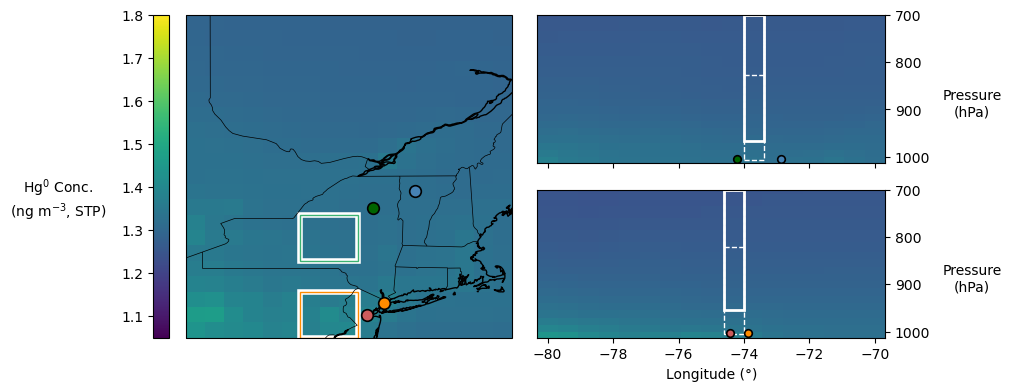

In [26]:
#key settings
vmin=1.05
vmax=1.8

ds = base_n

data=f.HgConversion(ds['SpeciesConcVV_Hg0'].mean('time').isel(lev=0))

fig, ax_dict = plt.subplot_mosaic([['left', 'top_right'],
                                   ['left', 'bottom_right']],
                                  figsize=(10,3.8),
                                  layout='constrained',
                                  sharex=True,
                                  )

ax_left = ax_dict['left']
ax_top_right = ax_dict['top_right']
ax_bottom_right = ax_dict['bottom_right']

ss = ax_left.get_subplotspec()
ax_left.remove()

ax_left = fig.add_subplot(ss, projection=ccrs.PlateCarree())
g = ax_left.pcolormesh(data.lon,data.lat,data,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True)
ax_left.add_feature(cfeature.COASTLINE,zorder=10)
ax_left.add_feature(cfeature.BORDERS,color=boarder,linewidth=0.5)
ax_left.add_feature(states_provinces,linewidth=0.5,zorder=10,edgecolor='black')

#urban uw box
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='darkorange',
                                transform=ccrs.PlateCarree(),linewidth=1))
#Rural uw box
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='mediumseagreen',
                                transform=ccrs.PlateCarree(),linewidth=1))

cbar = fig.colorbar(g,cax=ax_left.inset_axes([-0.1, 0, 0.05, 1]))
cbar.ax.yaxis.set_ticks_position('left')
cbar.set_label('Hg$^{0}$ Conc.\n(ng m$^{-3}$, STP)',rotation=0,labelpad=-80)
#cbar = fig.colorbar(g, orientation='horizontal',cax=ax_left.inset_axes([0, -0.07, 1, 0.05]))
#cbar.set_label('Hg$^{0}$ Concentration (ng m$^{-3}$, STP)')

#measurement sites
ax_left.scatter(bronx[0],bronx[1],marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_left.scatter(nbrunswick[0],nbrunswick[1],marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_left.scatter(underhill[0],underhill[1],marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_left.scatter(huntington[0],huntington[1],marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')

#now, adding the vertical cross section (urban)
urban_cs = ds.sel(lat=slice(urban_anchor[0],urban_anchor[0]+lat_extent))
urban_cs = f.HgConversion(urban_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_bottom_right.pcolormesh(urban_cs.lon,test_pressure,urban_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_bottom_right.set_ylim(700,1013)
ax_bottom_right.invert_yaxis()
ax_bottom_right.yaxis.tick_right()

ax_bottom_right.scatter(bronx[0],1003,marker='o',c='darkorange',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_bottom_right.scatter(nbrunswick[0],1003,marker='o',c='indianred',s=30,zorder=30,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
#ax_bottom_right.scatter(underhill[0],990,marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
#ax_bottom_right.scatter(huntington[0],990,marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_bottom_right.set_xlabel('Longitude (°)')
ax_bottom_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_bottom_right.yaxis.set_label_position('right')

#now, adding the vertical cross section (rural)
rural_cs = ds.sel(lat=slice(rural_anchor[0],rural_anchor[0]+lat_extent))
rural_cs = f.HgConversion(rural_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_top_right.pcolormesh(rural_cs.lon,test_pressure,rural_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_top_right.set_ylim(700,1013)
ax_top_right.invert_yaxis()
ax_top_right.yaxis.tick_right()

#ax_top_right.scatter(bronx[0],990,marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
#ax_top_right.scatter(nbrunswick[0],990,marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_top_right.scatter(underhill[0],1005,marker='o',c='steelblue',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_top_right.scatter(huntington[0],1005,marker='o',c='darkgreen',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_top_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_top_right.yaxis.set_label_position('right')

#now drawing boxes over areas used to calculate geoschem parameters
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.min()], width=0.625, height=700-pblp_rural.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.max()], width=0.625, height=700-pblp_rural.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.mean()], width=0.625, height=700-pblp_rural.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.min()], width=0.625, height=700-pblp_urban.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.max()], width=0.625, height=700-pblp_urban.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.mean()], width=0.625, height=700-pblp_urban.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

plt.savefig(figpath+'Supplemental_CUW_CFT_D_std.'+figformat,dpi=dpi,transparent=True)

In [23]:
#This is the 7x ne scale

/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


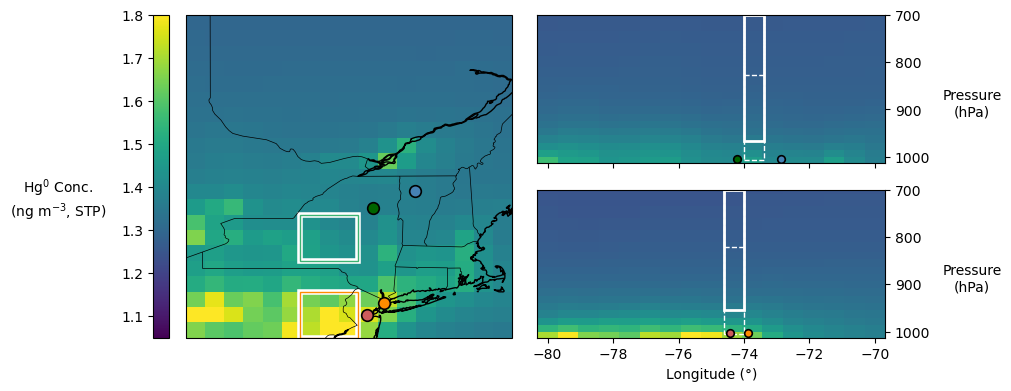

In [27]:
#key settings
vmin=1.05
vmax=1.8

ds = base_n_7x_nescale

data=f.HgConversion(ds['SpeciesConcVV_Hg0'].mean('time').isel(lev=0))

fig, ax_dict = plt.subplot_mosaic([['left', 'top_right'],
                                   ['left', 'bottom_right']],
                                  figsize=(10,3.8),
                                  layout='constrained',
                                  sharex=True,
                                  )

ax_left = ax_dict['left']
ax_top_right = ax_dict['top_right']
ax_bottom_right = ax_dict['bottom_right']

ss = ax_left.get_subplotspec()
ax_left.remove()

ax_left = fig.add_subplot(ss, projection=ccrs.PlateCarree())
g = ax_left.pcolormesh(data.lon,data.lat,data,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True)
ax_left.add_feature(cfeature.COASTLINE,zorder=10)
ax_left.add_feature(cfeature.BORDERS,color=boarder,linewidth=0.5)
ax_left.add_feature(states_provinces,linewidth=0.5,zorder=10,edgecolor='black')

#urban uw box
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='darkorange',
                                transform=ccrs.PlateCarree(),linewidth=1))
#Rural uw box
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='mediumseagreen',
                                transform=ccrs.PlateCarree(),linewidth=1))

cbar = fig.colorbar(g,cax=ax_left.inset_axes([-0.1, 0, 0.05, 1]))
cbar.ax.yaxis.set_ticks_position('left')
cbar.set_label('Hg$^{0}$ Conc.\n(ng m$^{-3}$, STP)',rotation=0,labelpad=-80)
#cbar = fig.colorbar(g, orientation='horizontal',cax=ax_left.inset_axes([0, -0.07, 1, 0.05]))
#cbar.set_label('Hg$^{0}$ Concentration (ng m$^{-3}$, STP)')

#measurement sites
ax_left.scatter(bronx[0],bronx[1],marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_left.scatter(nbrunswick[0],nbrunswick[1],marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_left.scatter(underhill[0],underhill[1],marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_left.scatter(huntington[0],huntington[1],marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')

#now, adding the vertical cross section (urban)
urban_cs = ds.sel(lat=slice(urban_anchor[0],urban_anchor[0]+lat_extent))
urban_cs = f.HgConversion(urban_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_bottom_right.pcolormesh(urban_cs.lon,test_pressure,urban_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_bottom_right.set_ylim(700,1013)
ax_bottom_right.invert_yaxis()
ax_bottom_right.yaxis.tick_right()

ax_bottom_right.scatter(bronx[0],1003,marker='o',c='darkorange',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_bottom_right.scatter(nbrunswick[0],1003,marker='o',c='indianred',s=30,zorder=30,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
#ax_bottom_right.scatter(underhill[0],990,marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
#ax_bottom_right.scatter(huntington[0],990,marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_bottom_right.set_xlabel('Longitude (°)')
ax_bottom_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_bottom_right.yaxis.set_label_position('right')

#now, adding the vertical cross section (rural)
rural_cs = ds.sel(lat=slice(rural_anchor[0],rural_anchor[0]+lat_extent))
rural_cs = f.HgConversion(rural_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_top_right.pcolormesh(rural_cs.lon,test_pressure,rural_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_top_right.set_ylim(700,1013)
ax_top_right.invert_yaxis()
ax_top_right.yaxis.tick_right()

#ax_top_right.scatter(bronx[0],990,marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
#ax_top_right.scatter(nbrunswick[0],990,marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_top_right.scatter(underhill[0],1005,marker='o',c='steelblue',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_top_right.scatter(huntington[0],1005,marker='o',c='darkgreen',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_top_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_top_right.yaxis.set_label_position('right')

#now drawing boxes over areas used to calculate geoschem parameters
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.min()], width=0.625, height=700-pblp_rural.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.max()], width=0.625, height=700-pblp_rural.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.mean()], width=0.625, height=700-pblp_rural.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.min()], width=0.625, height=700-pblp_urban.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.max()], width=0.625, height=700-pblp_urban.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.mean()], width=0.625, height=700-pblp_urban.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

plt.savefig(figpath+'Supplemental_CUW_CFT_D_7xnes.'+figformat,dpi=dpi,transparent=True)

/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


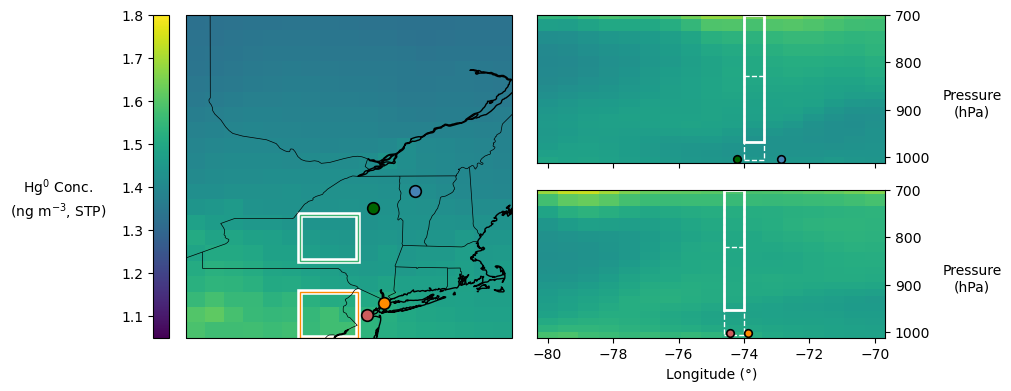

In [28]:
#key settings
vmin=1.05
vmax=1.8

ds = base_n_FTscale_t

data=f.HgConversion(ds['SpeciesConcVV_Hg0'].mean('time').isel(lev=0))

fig, ax_dict = plt.subplot_mosaic([['left', 'top_right'],
                                   ['left', 'bottom_right']],
                                  figsize=(10,3.8),
                                  layout='constrained',
                                  sharex=True,
                                  )

ax_left = ax_dict['left']
ax_top_right = ax_dict['top_right']
ax_bottom_right = ax_dict['bottom_right']

ss = ax_left.get_subplotspec()
ax_left.remove()

ax_left = fig.add_subplot(ss, projection=ccrs.PlateCarree())
g = ax_left.pcolormesh(data.lon,data.lat,data,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True)
ax_left.add_feature(cfeature.COASTLINE,zorder=10)
ax_left.add_feature(cfeature.BORDERS,color=boarder,linewidth=0.5)
ax_left.add_feature(states_provinces,linewidth=0.5,zorder=10,edgecolor='black')

#urban uw box
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[urban_anchor[1],urban_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='darkorange',
                                transform=ccrs.PlateCarree(),linewidth=1))
#Rural uw box
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='white',
                                transform=ccrs.PlateCarree(),linewidth=4))
ax_left.add_patch(mpatches.Rectangle(xy=[rural_anchor[1],rural_anchor[0]], width=lon_extent, height=lat_extent,
                                facecolor='none', edgecolor='mediumseagreen',
                                transform=ccrs.PlateCarree(),linewidth=1))

cbar = fig.colorbar(g,cax=ax_left.inset_axes([-0.1, 0, 0.05, 1]))
cbar.ax.yaxis.set_ticks_position('left')
cbar.set_label('Hg$^{0}$ Conc.\n(ng m$^{-3}$, STP)',rotation=0,labelpad=-80)
#cbar = fig.colorbar(g, orientation='horizontal',cax=ax_left.inset_axes([0, -0.07, 1, 0.05]))
#cbar.set_label('Hg$^{0}$ Concentration (ng m$^{-3}$, STP)')

#measurement sites
ax_left.scatter(bronx[0],bronx[1],marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_left.scatter(nbrunswick[0],nbrunswick[1],marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_left.scatter(underhill[0],underhill[1],marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_left.scatter(huntington[0],huntington[1],marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')

#now, adding the vertical cross section (urban)
urban_cs = ds.sel(lat=slice(urban_anchor[0],urban_anchor[0]+lat_extent))
urban_cs = f.HgConversion(urban_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_bottom_right.pcolormesh(urban_cs.lon,test_pressure,urban_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_bottom_right.set_ylim(700,1012)
ax_bottom_right.invert_yaxis()
ax_bottom_right.yaxis.tick_right()

ax_bottom_right.scatter(bronx[0],1003,marker='o',c='darkorange',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
ax_bottom_right.scatter(nbrunswick[0],1003,marker='o',c='indianred',s=30,zorder=30,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
#ax_bottom_right.scatter(underhill[0],990,marker='o',c='steelblue',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
#ax_bottom_right.scatter(huntington[0],990,marker='o',c='darkgreen',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_bottom_right.set_xlabel('Longitude (°)')
ax_bottom_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_bottom_right.yaxis.set_label_position('right')

#now, adding the vertical cross section (rural)
rural_cs = ds.sel(lat=slice(rural_anchor[0],rural_anchor[0]+lat_extent))
rural_cs = f.HgConversion(rural_cs['SpeciesConcVV_Hg0'].mean(('time','lat')))

ax_top_right.pcolormesh(rural_cs.lon,test_pressure,rural_cs,vmin=vmin,vmax=vmax,cmap='viridis',rasterized=True) #urban_cs.lev
ax_top_right.set_ylim(700,1012)
ax_top_right.invert_yaxis()
ax_top_right.yaxis.tick_right()

#ax_top_right.scatter(bronx[0],990,marker='o',c='darkorange',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='Bronx, NY')
#ax_top_right.scatter(nbrunswick[0],990,marker='o',c='indianred',s=70,zorder=10,edgecolors=boarder,linewidth=1.2,label='New Brunswick, NJ')
ax_top_right.scatter(underhill[0],1005,marker='o',c='steelblue',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Underhill, VT')
ax_top_right.scatter(huntington[0],1005,marker='o',c='darkgreen',s=30,zorder=10,edgecolors=boarder,linewidth=1.2,label='Huntington, NY')
ax_top_right.set_ylabel('Pressure\n(hPa)',rotation=0,labelpad=30)
ax_top_right.yaxis.set_label_position('right')

#now drawing boxes over areas used to calculate geoschem parameters
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.min()], width=0.625, height=700-pblp_rural.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.max()], width=0.625, height=700-pblp_rural.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_top_right.add_patch(mpatches.Rectangle(xy=[-74,pblp_rural.mean()], width=0.625, height=700-pblp_rural.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.min()], width=0.625, height=700-pblp_urban.min(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.max()], width=0.625, height=700-pblp_urban.max(),
                                facecolor='none', edgecolor='white',linewidth=1,linestyle='--'))
ax_bottom_right.add_patch(mpatches.Rectangle(xy=[-74-0.625,pblp_urban.mean()], width=0.625, height=700-pblp_urban.mean(),
                                facecolor='none', edgecolor='white',linewidth=2))

plt.savefig(figpath+'Supplemental_CUW_CFT_D_FTtuned.'+figformat,dpi=dpi,transparent=True)

In [150]:
#okay. So, in order to be consistent with solution space plots,
#I need to calculate CFT in the same way. Interesting.

In [154]:
#reading in compiled datasets with met and Hg0

bronx = [-73.8782,40.8680]
nbrunswick = [-74.4226,40.4728]
underhill = [-72.8684,44.5283]
huntington = [-74.2231,43.9731]

hg0path = '../../data/GCdata/GC_output/'

base = xr.open_dataset(hg0path+'STND/GEOSChem.SpeciesConcHF.2019.nc4').load()
nest = xr.open_dataset(hg0path+'NEST/GEOSChem.SpeciesConcHF.2019.nc4').load()
ant7 = xr.open_dataset(hg0path+'/ANT7/GEOSChem.SpeciesConcHF.2019.nc4').load()
cftscal = xr.open_dataset(hg0path+'/CFTSCAL/GEOSChem.SpeciesConcHF.2019.nc4').load()

#reading in files for boundary conditions
base_hy = xr.open_dataset(hg0path+'STND/GEOSChem.ProdLoss.20190101_0000z.nc4')[['hyai','hybi','P0']].load()
nest_hy = xr.open_dataset(hg0path+'NEST/GEOSChem.ProdLoss.20190101_0000z.nc4')[['hyai','hybi','P0']].load()

base = xr.merge([base,base_hy])
nest = xr.merge([nest,nest_hy])
ant7 = xr.merge([ant7,nest_hy])
cftscal = xr.merge([cftscal,nest_hy])

In [155]:
met = xr.open_mfdataset('../../data/pblh/MERRA2/MERRA2.2019*.pblh.2x25.nc4').load()

In [156]:
#defining the 1976 std atmosphere (using values from S&P)
p_stdatm = np.array([1013,898,795,701.2,616.6,540.5,472.2,411.1,356.5,308,265,227,194,165,142,121,103,88.5,75.6,64.6,5.53]) #converts from hPa to Pa
T_stdatm = np.array([288,282,275,269,262,256,249,243,236,230,223,217,217,217,217,217,217,217,217,217,217]) #K
z_stdatm = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20])*1000 #m

p_to_z = interp1d(p_stdatm,z_stdatm,fill_value='extrapolate')
z_to_p = interp1d(z_stdatm,p_stdatm,fill_value='extrapolate')

#p_to_z(1012)

In [157]:
%%capture --no-stdout

#calculating pressure at each gridbox
p_i = base['hyai']+(base['hybi']*(met['SLP'])/100)

In [158]:
%%capture --no-stdout

p_m = p_i.rolling(ilev=2).mean().dropna('ilev')

In [159]:
p_m = p_m.assign_coords(ilev=(base.lev.values))
p_m = p_m.rename({'ilev':'lev'})
p_m = p_m.sel(lat=base['lat'],lon=base['lon']).resample(time='1H').mean()
base_met = xr.merge([base,p_m.to_dataset(name='P_m')])

In [160]:
%%capture --no-stdout

rural = base_met.sel(lon=huntington[0],lat=huntington[1],method='nearest')
urban = base_met.sel(lon=nbrunswick[0],lat=nbrunswick[1],method='nearest')

In [161]:
%%capture --no-stdout

pblh_rural = met['PBLH'].sel(lon=huntington[0],lat=huntington[1],method='nearest')
pblh_urban = met['PBLH'].sel(lon=nbrunswick[0],lat=nbrunswick[1],method='nearest')

pblp_rural = z_to_p(pblh_rural.values)
pblp_urban = z_to_p(pblh_urban.values)

In [162]:
test_pressure = base_met.mean(('time','lat','lon'))['P_m']

In [163]:
def conc_partition(conc,pblp,convert=True,upper_thresh=700,export=True,path='/PROVIDEPATH/',name='rural'):
    '''
    Script partitions free tropospheric and PBL concentrations based on GC values.
    Before running, make sure that conc has been read in fully (i.e., conc = conc.load())
    '''
    for i in list(range(0,len(conc.time))): 
        temp_r = conc.isel(time=i)
        thresh = pblp[i]

        pbl_all = temp_r['SpeciesConcVV_Hg0'].where(temp_r['P_m']>thresh,drop=True)
        pbl_i = pbl_all.mean('lev')
        ft_all = temp_r['SpeciesConcVV_Hg0'].where(temp_r['P_m']<thresh,drop=True).where(temp_r['P_m']>upper_thresh,drop=True)
        ft_i = ft_all.mean('lev')

        if i == 0:
            pbl = pbl_i
            ft = ft_i
            levs = np.array(len(pbl_all))
            levs_ft = np.array(len(ft_all))
        else:
            pbl = xr.concat([pbl,pbl_i],dim='time')
            ft = xr.concat([ft,ft_i],dim='time')
            levs = np.append(levs,len(pbl_all))
            levs_ft = np.append(levs_ft,len(ft_all))
            
    if convert==True:       
        pbl = f.HgConversion(pbl)
        ft = f.HgConversion(ft)
    
    if export==True:
        np.save(path+name+'_pbl.npy',pbl)
        np.save(path+name+'_ft.npy',ft)
        #np.save(path+name+'_levs_pbl.npy',levs)
        #np.save(path+name+'_levs_ft.npy',levs_ft)

    return pbl,ft,levs,levs_ft


In [164]:
rural_conc_pbl,rural_conc_ft,rural_levs,rural_levs_ft = conc_partition(rural,
                                                                       pblp_rural,
                                                                       export=False,
                                                                       path='false',
                                                                       name='rural_2019')

In [165]:
urban_conc_pbl,urban_conc_ft,urban_levs,urban_levs_ft = conc_partition(urban,
                                                                       pblp_urban,
                                                                       export=False,
                                                                       path='false',
                                                                       name='urban_2019')

In [166]:
def conc_partition_nest_simple(gc,pbl,ft):
    for i in list(range(0,len(pbl))):
        pbl_i = f.HgConversion(gc.isel(time=i,lev=slice(0,pbl[i]))['SpeciesConcVV_Hg0'].mean().values)
        ft_i = f.HgConversion(gc.isel(time=i,lev=slice(pbl[i],ft[i]))['SpeciesConcVV_Hg0'].mean().values)
        
        if i == 0:
            pbl_conc = np.array(pbl_i)
            ft_conc = np.array(ft_i)
        else:
            pbl_conc = np.append(pbl_conc,pbl_i)
            ft_conc = np.append(ft_conc,ft_i)        
    return pbl_conc,ft_conc


In [167]:
%%capture --no-stdout

#define location of midpoint
r_lon = (huntington[0]+underhill[0])/2
r_lat = (huntington[1]+underhill[1])/2
u_lon = (nbrunswick[0]+bronx[0])/2
u_lat = (nbrunswick[1]+bronx[1])/2
#select location of temporally varying vertical profile

rural_nest = nest.sel(lon=r_lon,lat=r_lat,method='nearest')
urban_nest = nest.sel(lon=u_lon,lat=u_lat,method='nearest')

rural_ant7 = ant7.sel(lon=r_lon,lat=r_lat,method='nearest')
urban_ant7 = ant7.sel(lon=u_lon,lat=u_lat,method='nearest')

rural_cftscal = cftscal.sel(lon=r_lon,lat=r_lat,method='nearest')
urban_cftscal = cftscal.sel(lon=u_lon,lat=u_lat,method='nearest')

In [168]:
rural_nest_pbl,rural_nest_ft = conc_partition_nest_simple(rural_nest,
                                                rural_levs,
                                                rural_levs_ft)

urban_nest_pbl,urban_nest_ft = conc_partition_nest_simple(urban_nest,
                                                urban_levs,
                                                urban_levs_ft)

In [169]:
rural_ant7_pbl,rural_ant7_ft = conc_partition_nest_simple(rural_ant7,
                                                rural_levs,
                                                rural_levs_ft)

urban_ant7_pbl,urban_ant7_ft = conc_partition_nest_simple(urban_ant7,
                                                urban_levs,
                                                urban_levs_ft)

In [170]:
rural_cftscal_pbl,rural_cftscal_ft = conc_partition_nest_simple(rural_cftscal,
                                                rural_levs,
                                                rural_levs_ft)

urban_cftscal_pbl,urban_cftscal_ft = conc_partition_nest_simple(urban_cftscal,
                                                urban_levs,
                                                urban_levs_ft)

In [171]:
datetime = pd.date_range('01-01-2019 00:00','12-31-2019 23:59',freq='1H')

In [172]:
pbl = pd.DataFrame({'r_nest':rural_nest_pbl,
                   'u_nest':urban_nest_pbl,
                   'r_ant7':rural_ant7_pbl,
                   'u_ant7':urban_ant7_pbl,
                   'r_cftscal':rural_cftscal_pbl,
                   'u_cftscal':urban_cftscal_pbl},index=datetime)

ft = pd.DataFrame({'r_nest':rural_nest_ft,
                   'u_nest':urban_nest_ft,
                   'r_ant7':rural_ant7_ft,
                   'u_ant7':urban_ant7_ft,
                   'r_cftscal':rural_cftscal_ft,
                   'u_cftscal':urban_cftscal_ft},index=datetime)

pbl_m = pbl.resample('1M').mean()
ft_m = ft.resample('1M').mean()

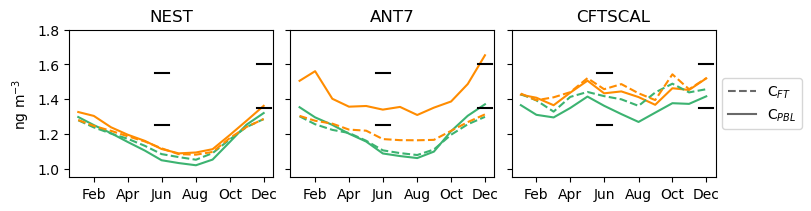

In [175]:
#now, creating a supplemental figure to show the different FT seasonalities
months = np.arange(0,12,1)+1
ms = ['2019-02-28','2019-04-30','2019-06-30', '2019-08-31','2019-10-31', '2019-12-31']#[2,4,6,8,10,12]
ms_name = ['Feb','Apr','Jun','Aug','Oct','Dec']

fig,ax=plt.subplots(1,3,figsize=(8,2),sharex=True,sharey=True,layout='constrained')

ax[0].plot(pbl_m['r_nest'],c='mediumseagreen')
ax[0].plot(pbl_m['u_nest'],c='darkorange')
ax[0].plot(ft_m['r_nest'],c='mediumseagreen',linestyle='--')
ax[0].plot(ft_m['u_nest'],c='darkorange',linestyle='--')

ax[1].plot(pbl_m['r_ant7'],c='mediumseagreen')
ax[1].plot(pbl_m['u_ant7'],c='darkorange')
ax[1].plot(ft_m['r_ant7'],c='mediumseagreen',linestyle='--')
ax[1].plot(ft_m['u_ant7'],c='darkorange',linestyle='--')

ax[2].plot(pbl_m['r_cftscal'],c='mediumseagreen')
ax[2].plot(pbl_m['u_cftscal'],c='darkorange')
ax[2].plot(ft_m['r_cftscal'],c='mediumseagreen',linestyle='--')
ax[2].plot(ft_m['u_cftscal'],c='darkorange',linestyle='--')

ax[2].set_xticks(ms)
ax[2].set_xticklabels(ms_name)

ax[0].set_title('NEST')
ax[1].set_title('ANT7')
ax[2].set_title('CFTSCAL')

for i in ax:
    i.axhline(1.6,xmin=0.92,xmax=0.99,c='black')
    i.axhline(1.35,xmin=0.92,xmax=0.99,c='black')
    i.axhline(1.55,xmin=0.42,xmax=0.49,c='black')
    i.axhline(1.25,xmin=0.42,xmax=0.49,c='black')

ax[2].plot(ft_m['r_cftscal']*20,c='dimgray',linestyle='--',label='C$_{FT}$')
ax[2].plot(pbl_m['u_cftscal']*20,c='dimgray',label='C$_{PBL}$')
ax[2].legend(loc='center left',bbox_to_anchor=(1,0.5))
ax[2].set_ylim(0.95,1.8)
ax[0].set_ylabel('ng m$^{-3}$')
plt.savefig(figpath+'Supplemental_SeasonalFTConstraintVariation.'+figformat,dpi=dpi,transparent=True)